# Interaction Fingerprinting Analysis — Parameter Sensitivity Edition

This notebook analyzes residue-level contacts between **the final-pass validated designs** from the parameter sensitivity study and PD-L1, then compares those contacts to native PD-1/PD-L1 contacts from 4ZQK.

**Key updates from the original notebook:**
- Driven by the validation CSVs (not directory scanning)
- Per-condition hotspot definitions (clusterA / clusterB / distributed)
- Pass/fail tagging on every design
- Grouped analyses by hotspot config and pass/fail status
- Structured JSON export for the portfolio page

**Compute note:** CPU-only. No GPU required.

**Clean-up note (June 2026):** This version locks hotspot definitions to the RFdiffusion parameter sweep in notebook 06, removes the hallucinated full-sidechain hotspot map, keeps closest atom-pair records for residue contacts, and renames extended metrics whose interpretation is approximate.


In [1]:
# ============================================================
# Cell 0: Install dependencies
# ============================================================
!pip -q install biopython pandas numpy matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 24.4 MB/s eta 0:00:00


In [2]:
# ============================================================
# Cell 1: Mount Drive and set project paths
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import json
from pathlib import Path

# ── PROJECT PATHS ──
# These match the param_sensitivity_runner notebook.
# >>> VERIFY: If your Drive path differs, update PROJECT_DIR below. <<<
PROJECT_DIR = Path("/content/drive/Othercomputers/My Mac/pdl1-mini-binder-design")

DATA_DIR      = PROJECT_DIR / "data"
RESULTS_DIR   = DATA_DIR / "results"
STRUCTURES_DIR = DATA_DIR / "structures"
STUDY_DIR     = RESULTS_DIR / "param_sensitivity"

# Native PD-1/PD-L1 reference structure
NATIVE_PDB = STRUCTURES_DIR / "pdb4zqk.ent"

# ── VALIDATION CSVs ──
# The runner produces these. Check STUDY_DIR first, then PROJECT_DIR root.
# >>> MANUAL FIX: If the CSVs are elsewhere, update these paths. <<<
VALIDATION_CSV = None
RANKED_CSV = None

for search_dir in [STUDY_DIR, PROJECT_DIR, RESULTS_DIR]:
    candidate = search_dir / "all_conditions_validation_results.csv"
    if candidate.exists():
        VALIDATION_CSV = candidate
        break

for search_dir in [STUDY_DIR, PROJECT_DIR, RESULTS_DIR]:
    candidate = search_dir / "ranked_candidates_all_conditions.csv"
    if candidate.exists():
        RANKED_CSV = candidate
        break

# Output directory
OUTPUT_DIR = RESULTS_DIR / "fingerprinting_param_sensitivity"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Validate paths ──
print("PROJECT_DIR:", PROJECT_DIR, "exists:", PROJECT_DIR.exists())
print("STUDY_DIR:  ", STUDY_DIR, "exists:", STUDY_DIR.exists())
print("NATIVE_PDB: ", NATIVE_PDB, "exists:", NATIVE_PDB.exists())
print("VALIDATION_CSV:", VALIDATION_CSV, "exists:", VALIDATION_CSV.exists() if VALIDATION_CSV else "NOT FOUND")
print("RANKED_CSV:   ", RANKED_CSV, "exists:", RANKED_CSV.exists() if RANKED_CSV else "NOT FOUND")
print("OUTPUT_DIR: ", OUTPUT_DIR)

for name, path in [("PROJECT_DIR", PROJECT_DIR), ("STUDY_DIR", STUDY_DIR), ("NATIVE_PDB", NATIVE_PDB)]:
    if not path.exists():
        raise FileNotFoundError(f"{name} does not exist: {path}")

if VALIDATION_CSV is None or RANKED_CSV is None:
    raise FileNotFoundError(
        "Could not find validation CSVs. Looked in STUDY_DIR, PROJECT_DIR, and RESULTS_DIR.\n"
        "Please set VALIDATION_CSV and RANKED_CSV manually to the correct paths."
    )


Mounted at /content/drive
PROJECT_DIR: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design exists: True
STUDY_DIR:   /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/param_sensitivity exists: True
NATIVE_PDB:  /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/structures/pdb4zqk.ent exists: True
VALIDATION_CSV: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/param_sensitivity/all_conditions_validation_results.csv exists: True
RANKED_CSV:    /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/param_sensitivity/ranked_candidates_all_conditions.csv exists: True
OUTPUT_DIR:  /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/fingerprinting_param_sensitivity


In [3]:
# ============================================================
# Cell 2: Imports and helpers
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from Bio.PDB import PDBParser, NeighborSearch
from Bio.PDB.Polypeptide import is_aa
from Bio.Data.IUPACData import protein_letters_3to1

parser = PDBParser(QUIET=True)

def three_to_one_safe(resname):
    """Convert 3-letter AA code to 1-letter. Stable across Biopython versions.
    Returns 'X' for non-standard residues with a warning."""
    key = str(resname).capitalize()
    code = protein_letters_3to1.get(key)
    if code is None:
        import warnings
        warnings.warn(f"Non-standard residue '{resname}' mapped to 'X'", stacklevel=2)
        return "X"
    return code

print("Imports loaded")


Imports loaded


In [4]:
# ============================================================
# Cell 3: Authoritative hotspot definitions and condition parsing
# ============================================================
# These are the hotspot configurations used by 06_param_sensitivity_runner.ipynb
# / conditions.csv for the RFdiffusion parameter sweep.
#
# IMPORTANT:
#   These residue numbers are the source of truth for hotspot-dependent
#   analyses. Do not redefine them later in the notebook.
#
# RFdiffusion hotspot strings:
#   clusterA:    A18,A20,A120,A122
#   clusterB:    A26,A56,A113,A123,A125
#   distributed: A18,A20,A26,A56,A113,A120,A122,A125

HOTSPOT_MAP_AUTHORITATIVE = {
    "clusterA":    [18, 20, 120, 122],
    "clusterB":    [26, 56, 113, 123, 125],
    "distributed": [18, 20, 26, 56, 113, 120, 122, 125],
}

# Use this single name everywhere downstream for backward compatibility.
HOTSPOT_MAP = HOTSPOT_MAP_AUTHORITATIVE

# Hard guard against accidental or hallucinated hotspot redefinition.
EXPECTED_HOTSPOT_MAP = {
    "clusterA":    [18, 20, 120, 122],
    "clusterB":    [26, 56, 113, 123, 125],
    "distributed": [18, 20, 26, 56, 113, 120, 122, 125],
}
assert HOTSPOT_MAP == EXPECTED_HOTSPOT_MAP, (
    "HOTSPOT_MAP differs from the RFdiffusion parameter sweep definitions. "
    f"Current: {HOTSPOT_MAP}; Expected: {EXPECTED_HOTSPOT_MAP}"
)

# Union of all hotspot positions — used for hotspot comparisons.
ALL_HOTSPOTS = sorted(set().union(*HOTSPOT_MAP.values()))
print(f"Authoritative hotspot map: {HOTSPOT_MAP}")
print(f"All hotspot positions (union): {ALL_HOTSPOTS}")

def get_hotspot_config(condition_id):
    """Parse condition_id string to return the hotspot config name."""
    for key in HOTSPOT_MAP:
        if f"_{key}_" in condition_id:
            return key
    raise ValueError(f"Cannot parse hotspot config from: {condition_id}")

def parse_condition(condition_id):
    """Parse condition_id into length, hotspot config, and noise scale."""
    length = int(re.search(r"len(\d+)", condition_id).group(1))
    hotspot = get_hotspot_config(condition_id)
    noise = 0.5 if "noise05" in condition_id else 0.0
    return length, hotspot, noise

# Quick test
for cid in ["len70_clusterA_noise0", "len100_clusterB_noise05", "len50_distributed_noise0"]:
    l, h, n = parse_condition(cid)
    print(f"  {cid} -> len={l}, hotspot={h} ({HOTSPOT_MAP[h]}), noise={n}")


Authoritative hotspot map: {'clusterA': [18, 20, 120, 122], 'clusterB': [26, 56, 113, 123, 125], 'distributed': [18, 20, 26, 56, 113, 120, 122, 125]}
All hotspot positions (union): [18, 20, 26, 56, 113, 120, 122, 123, 125]
  len70_clusterA_noise0 -> len=70, hotspot=clusterA ([18, 20, 120, 122]), noise=0.0
  len100_clusterB_noise05 -> len=100, hotspot=clusterB ([26, 56, 113, 123, 125]), noise=0.5
  len50_distributed_noise0 -> len=50, hotspot=distributed ([18, 20, 26, 56, 113, 120, 122, 125]), noise=0.0


In [5]:
# ============================================================
# Cell 4: Build final-pass design manifest from runner CSVs
# ============================================================
# This notebook should analyze only final-pass designs.
#
# Geometry comes from:
#   designed_pdb  = RFdiffusion binder-target complex backbone
#
# Residue identity comes from:
#   binder_sequence = ProteinMPNN-designed sequence
#
# Therefore, the contact geometry is taken from designed_pdb, but binder residue
# names must be overwritten using binder_sequence during contact extraction.

df_validated = pd.read_csv(VALIDATION_CSV)
df_ranked = pd.read_csv(RANKED_CSV)

print("Validated CSV rows:", len(df_validated))
print("Ranked CSV rows:   ", len(df_ranked))

# ------------------------------------------------------------
# Add / recover passes_final_filter
# ------------------------------------------------------------

if "passes_final_filter" not in df_validated.columns:
    if "passes_final_filter" not in df_ranked.columns:
        raise RuntimeError(
            "Neither validation CSV nor ranked CSV contains passes_final_filter."
        )

    pass_cols = ["condition_id", "seq_id", "passes_final_filter"]
    pass_cols = [c for c in pass_cols if c in df_ranked.columns]

    df_manifest = df_validated.merge(
        df_ranked[pass_cols].drop_duplicates(),
        on=[c for c in ["condition_id", "seq_id"] if c in df_validated.columns and c in df_ranked.columns],
        how="left"
    )
else:
    df_manifest = df_validated.copy()

df_manifest["passes_final_filter"] = df_manifest["passes_final_filter"].fillna(False).astype(bool)

# ------------------------------------------------------------
# Recover binder_sequence if missing from validation_results
# ------------------------------------------------------------

if "binder_sequence" not in df_manifest.columns or df_manifest["binder_sequence"].isna().all():
    print("binder_sequence missing from validation CSV. Recovering from per-condition ESMFold prediction CSVs...")

    sequence_tables = []

    for cond_id in sorted(df_manifest["condition_id"].dropna().unique()):
        pred_csv = STUDY_DIR / cond_id / "esmfold_predictions" / "esmfold_binder_predictions.csv"

        if not pred_csv.exists():
            print(f"  Missing sequence CSV for {cond_id}: {pred_csv}")
            continue

        df_pred = pd.read_csv(pred_csv)

        keep_cols = [
            c for c in [
                "condition_id",
                "seq_id",
                "backbone",
                "binder_sequence",
                "binder_length",
            ]
            if c in df_pred.columns
        ]

        sequence_tables.append(df_pred[keep_cols].drop_duplicates())

    if not sequence_tables:
        raise RuntimeError(
            "Could not recover binder_sequence. No esmfold_binder_predictions.csv files found."
        )

    df_sequences = pd.concat(sequence_tables, ignore_index=True)

    merge_keys = [
        c for c in ["condition_id", "seq_id", "backbone"]
        if c in df_manifest.columns and c in df_sequences.columns
    ]

    print("Merging binder sequences using keys:", merge_keys)

    df_manifest = df_manifest.merge(
        df_sequences,
        on=merge_keys,
        how="left",
        suffixes=("", "_recovered")
    )

    if "binder_sequence_recovered" in df_manifest.columns:
        df_manifest["binder_sequence"] = df_manifest["binder_sequence"].fillna(
            df_manifest["binder_sequence_recovered"]
        )

    if "binder_length_recovered" in df_manifest.columns and "binder_length" not in df_manifest.columns:
        df_manifest["binder_length"] = df_manifest["binder_length_recovered"]

# ------------------------------------------------------------
# Add parsed condition metadata
# ------------------------------------------------------------

df_manifest["length"] = df_manifest["condition_id"].apply(lambda x: parse_condition(x)[0])
df_manifest["hotspot_config"] = df_manifest["condition_id"].apply(lambda x: parse_condition(x)[1])
df_manifest["noise"] = df_manifest["condition_id"].apply(lambda x: parse_condition(x)[2])

# ------------------------------------------------------------
# Validate designed_pdb paths
# ------------------------------------------------------------

if "designed_pdb" not in df_manifest.columns:
    raise RuntimeError("df_manifest does not contain designed_pdb.")

if "binder_sequence" not in df_manifest.columns:
    raise RuntimeError("df_manifest does not contain binder_sequence after recovery attempt.")

def resolve_existing_pdb(row):
    candidates = []

    if pd.notna(row.get("designed_pdb", None)):
        candidates.append(Path(str(row["designed_pdb"])))

    if pd.notna(row.get("pdb_path", None)):
        candidates.append(Path(str(row["pdb_path"])))

    for p in candidates:
        if p.exists():
            return str(p)

    return None

df_manifest["resolved_designed_pdb"] = df_manifest.apply(resolve_existing_pdb, axis=1)
df_manifest["pdb_exists"] = df_manifest["resolved_designed_pdb"].notna()

df_manifest["binder_sequence"] = df_manifest["binder_sequence"].astype(str).str.strip()
df_manifest["binder_sequence_ok"] = (
    df_manifest["binder_sequence"].notna()
    & (df_manifest["binder_sequence"] != "")
    & (df_manifest["binder_sequence"] != "nan")
)

print("\nBefore final-pass filtering:")
print("  Total rows:             ", len(df_manifest))
print("  Pass final filter:      ", df_manifest["passes_final_filter"].sum())
print("  Existing designed_pdb:  ", df_manifest["pdb_exists"].sum())
print("  Binder sequence present:", df_manifest["binder_sequence_ok"].sum())

# ------------------------------------------------------------
# CRITICAL FILTER:
# Only final-pass designs are analyzed downstream.
# ------------------------------------------------------------

df_manifest_all = df_manifest.copy()

df_manifest = df_manifest[
    df_manifest["passes_final_filter"]
    & df_manifest["pdb_exists"]
    & df_manifest["binder_sequence_ok"]
].copy()

df_manifest["designed_pdb"] = df_manifest["resolved_designed_pdb"]

print("\nProceeding with final-pass designs only:")
print("  Designs analyzed:", len(df_manifest))

if len(df_manifest) == 0:
    raise RuntimeError(
        "No usable final-pass designs remain. Check passes_final_filter, designed_pdb paths, and binder_sequence recovery."
    )

display_cols = [
    "condition_id",
    "seq_id",
    "backbone",
    "length",
    "hotspot_config",
    "noise",
    "binder_sequence",
    "mean_plddt",
    "rmsd",
    "passes_final_filter",
    "designed_pdb",
]

display(df_manifest[[c for c in display_cols if c in df_manifest.columns]].head(10))

Validated CSV rows: 55
Ranked CSV rows:    55
binder_sequence missing from validation CSV. Recovering from per-condition ESMFold prediction CSVs...
Merging binder sequences using keys: ['condition_id', 'seq_id', 'backbone']

Before final-pass filtering:
  Total rows:              55
  Pass final filter:       31
  Existing designed_pdb:   55
  Binder sequence present: 55

Proceeding with final-pass designs only:
  Designs analyzed: 31


,condition_id,seq_id,backbone,length,hotspot_config,noise,binder_sequence,mean_plddt,rmsd,passes_final_filter,designed_pdb
0,len25_clusterA_noise0,design_15_0_rank0,design_15_0,25,clusterA,0.0,SARLDALRAAAAAAAAAAAAAAAAA,96.85,0.56,True,/content/drive/Othercomputers/My Mac/pdl1-mini...
1,len25_clusterA_noise0,design_11_0_rank1,design_11_0,25,clusterA,0.0,SKATSEALEALARAAGAAAAAAAAA,94.83,0.41,True,/content/drive/Othercomputers/My Mac/pdl1-mini...
2,len50_clusterA_noise0,design_9_0_rank0,design_9_0,50,clusterA,0.0,MTREEGIEALRAAVEAAGAAAIAAAAADPAAAAAAEAARAAALAGL...,92.29,1.01,True,/content/drive/Othercomputers/My Mac/pdl1-mini...
5,len50_clusterA_noise05,design_0_0_rank0,design_0_0,50,clusterA,0.5,SELAALKARLTARYDQAAARVPAEKAPLVAQYRAALTAKIEAEAAA...,84.63,1.24,True,/content/drive/Othercomputers/My Mac/pdl1-mini...
6,len50_clusterB_noise0,design_19_0_rank0,design_19_0,50,clusterB,0.0,SAAAEAKAEQDAAIAALNAAAAAAAAAGDTAAAANARAGAAVLAKA...,94.74,0.70,True,/content/drive/Othercomputers/My Mac/pdl1-mini...
7,len50_distributed_noise0,design_4_0_rank0,design_4_0,50,distributed,0.0,AAALAAAAAAAAAAGAQAAALAAAGAAAAEINAAVAQALALAKQAD...,95.67,0.84,True,/content/drive/Othercomputers/My Mac/pdl1-mini...
12,len70_clusterA_noise0,design_10_0_rank1,design_10_0,70,clusterA,0.0,GALKEAIAASADASLAAGAAAAATDAAKGAALFAGAAAAYKLTGLA...,87.49,1.46,True,/content/drive/Othercomputers/My Mac/pdl1-mini...
16,len70_clusterA_noise0,design_16_0_rank5,design_16_0,70,clusterA,0.0,SAATRAAAQAAAAALAAAAAAAAAAAAAAENAAAAAAGTLTPAAAA...,95.07,0.55,True,/content/drive/Othercomputers/My Mac/pdl1-mini...
17,len70_clusterA_noise0,design_7_0_rank6,design_7_0,70,clusterA,0.0,SQAAGQALFKAQIANQAAAAYNAKAAALNAQAAADPAKAAELAAQA...,95.43,0.88,True,/content/drive/Othercomputers/My Mac/pdl1-mini...
18,len70_clusterA_noise0,design_3_0_rank7,design_3_0,70,clusterA,0.0,EERELDLAAARALANAAAVLAADPALAAAAAELAAAAAAFAEGAAN...,96.50,0.45,True,/content/drive/Othercomputers/My Mac/pdl1-mini...


In [6]:
# ============================================================
# Cell 5: Residue and interaction classification
# ============================================================

HYDROPHOBIC = set("AVILMFWP")
POLAR = set("STNQYC")
POSITIVE = set("KRH")
NEGATIVE = set("DE")
AROMATIC = set("FWY")

def classify_residue(one_letter):
    if one_letter in POSITIVE:  return "positive"
    if one_letter in NEGATIVE:  return "negative"
    if one_letter in AROMATIC:  return "aromatic"
    if one_letter in HYDROPHOBIC: return "hydrophobic"
    if one_letter in POLAR:     return "polar"
    return "other"

def classify_interaction(res1_class, res2_class):
    pair = frozenset([res1_class, res2_class])
    if pair == frozenset(["positive", "negative"]): return "salt_bridge"
    if "aromatic" in pair and len(pair) == 1:       return "aromatic_stacking"
    if pair == frozenset(["aromatic", "positive"]):  return "cation_pi"
    hydrophobic_types = {"hydrophobic", "aromatic"}
    if res1_class in hydrophobic_types and res2_class in hydrophobic_types:
        return "hydrophobic"
    hbond_types = {"polar", "positive", "negative"}
    if res1_class in hbond_types and res2_class in hbond_types:
        return "hydrogen_bond"
    return "mixed"

print("Classification functions defined")


Classification functions defined


In [7]:
# ============================================================
# Cell 6: Contact extraction functions
# ============================================================
# Native PD-1 contacts use residue identities from the native PDB.
#
# Designed binder contacts use:
#   - geometry from RFdiffusion designed_pdb
#   - binder residue identities from ProteinMPNN binder_sequence
#
# This prevents the poly-glycine RFdiffusion backbone from contaminating
# residue-identity analyses.

def get_standard_residues(chain):
    return [r for r in chain.get_residues() if r.id[0] == " " and is_aa(r, standard=True)]

def pick_chain(model, chain_id):
    if chain_id is None or pd.isna(chain_id):
        return None
    chain_id = str(chain_id)
    if chain_id in [c.id for c in model.get_chains()]:
        return model[chain_id]
    return None

def extract_contacts(
    pdb_path,
    contact_cutoff=4.5,
    binder_chain_id=None,
    target_chain_id=None,
    binder_sequence=None,
):
    """
    Extract residue-level contacts between binder and target.

    If binder_sequence is provided, binder residue identities are taken from
    binder_sequence by residue order, not from the PDB residue names.

    This is required for RFdiffusion complex backbones, where the binder chain
    may be poly-Gly even though ProteinMPNN designed a real sequence.
    """

    pdb_path = Path(pdb_path)
    structure = parser.get_structure("complex", str(pdb_path))
    model = structure[0]

    chains = list(model.get_chains())

    binder_chain = pick_chain(model, binder_chain_id)
    target_chain = pick_chain(model, target_chain_id)

    if binder_chain is None or target_chain is None:
        # Preferred default for this project:
        # 4ZQK and RFdiffusion complexes use A = PD-L1 target, B = binder.
        if "B" in [c.id for c in chains] and "A" in [c.id for c in chains]:
            binder_chain = model["B"]
            target_chain = model["A"]
        else:
            # Fallback: shortest chain = binder, longest chain = target.
            chains_by_size = sorted(chains, key=lambda c: len(get_standard_residues(c)))
            binder_chain = chains_by_size[0]
            target_chain = chains_by_size[-1]

    binder_residues = get_standard_residues(binder_chain)
    target_residues = get_standard_residues(target_chain)

    # Map binder residue number -> designed amino acid.
    # For native contacts, binder_sequence is None and identities are read from the PDB.
    binder_seq_map = None
    if binder_sequence is not None:
        binder_sequence = str(binder_sequence).strip()

        if len(binder_sequence) != len(binder_residues):
            raise ValueError(
                f"Binder sequence length mismatch for {pdb_path.name}: "
                f"sequence length={len(binder_sequence)}, "
                f"PDB binder residues={len(binder_residues)}"
            )

        binder_seq_map = {
            residue.id[1]: binder_sequence[i]
            for i, residue in enumerate(binder_residues)
        }

    target_atoms = []
    for residue in target_residues:
        for atom in residue.get_atoms():
            target_atoms.append(atom)

    ns = NeighborSearch(target_atoms)

    contacts = []
    seen = set()

    for b_res in binder_residues:
        b_resnum = b_res.id[1]

        if binder_seq_map is not None:
            b_aa = binder_seq_map[b_resnum]
        else:
            b_aa = three_to_one_safe(b_res.get_resname())

        b_class = classify_residue(b_aa)

        for b_atom in b_res.get_atoms():
            neighbors = ns.search(b_atom.get_coord(), contact_cutoff)

            for t_atom in neighbors:
                t_res = t_atom.get_parent()

                if t_res.id[0] != " " or not is_aa(t_res, standard=True):
                    continue

                t_resnum = t_res.id[1]
                key = (b_resnum, t_resnum)

                if key in seen:
                    continue

                seen.add(key)

                t_aa = three_to_one_safe(t_res.get_resname())
                t_class = classify_residue(t_aa)

                contacts.append({
                    "binder_chain": binder_chain.id,
                    "target_chain": target_chain.id,
                    "binder_resnum": b_resnum,
                    "binder_resname": b_aa,
                    "binder_class": b_class,
                    "target_resnum": t_resnum,
                    "target_resname": t_aa,
                    "target_class": t_class,
                    "interaction_type": classify_interaction(b_class, t_class),
                    "contact_cutoff": contact_cutoff,
                })

    chain_sizes = [
        (c, len(get_standard_residues(c)))
        for c in model.get_chains()
    ]

    return contacts, chain_sizes

print("Contact extraction function defined")

Contact extraction function defined


In [8]:
# ============================================================
# Cell 7: Extract native PD-1/PD-L1 contacts from 4ZQK
# ============================================================
# In 4ZQK: chain A = PD-L1 (target), chain B = PD-1 (natural binder).

print("Extracting native PD-1/PD-L1 contacts from 4ZQK...")

native_contacts, native_chain_sizes = extract_contacts(
    NATIVE_PDB,
    contact_cutoff=4.5,
    binder_chain_id="B",   # PD-1
    target_chain_id="A",   # PD-L1
    binder_sequence=None,  # use native PDB residue identities
)

df_native = pd.DataFrame(native_contacts)

print(f"Native chain sizes: {[(c.id, n) for c, n in native_chain_sizes]}")
print(f"Native PD-1/PD-L1 contacts: {len(df_native)} residue pairs")
print(f"PD-L1 residues contacted by PD-1: {sorted(df_native['target_resnum'].unique())}")

if len(df_native) == 0:
    raise RuntimeError("No native contacts found. Check chain IDs and PDB numbering.")

df_native.to_csv(OUTPUT_DIR / "native_pd1_contacts.csv", index=False)
df_native.head()


Extracting native PD-1/PD-L1 contacts from 4ZQK...
Native chain sizes: [('A', 115), ('B', 106)]
Native PD-1/PD-L1 contacts: 46 residue pairs
PD-L1 residues contacted by PD-1: [np.int64(19), np.int64(23), np.int64(26), np.int64(54), np.int64(56), np.int64(58), np.int64(66), np.int64(76), np.int64(113), np.int64(115), np.int64(117), np.int64(119), np.int64(120), np.int64(121), np.int64(122), np.int64(123), np.int64(124), np.int64(125)]


,binder_chain,target_chain,binder_resnum,binder_resname,binder_class,target_resnum,target_resname,target_class,interaction_type,contact_cutoff
0,B,A,64,V,hydrophobic,121,A,hydrophobic,hydrophobic,4.5
1,B,A,66,N,polar,121,A,hydrophobic,mixed,4.5
2,B,A,66,N,polar,122,D,negative,hydrogen_bond,4.5
3,B,A,68,Y,aromatic,122,D,negative,mixed,4.5
4,B,A,68,Y,aromatic,123,Y,aromatic,aromatic_stacking,4.5


In [9]:
# ============================================================
# Cell 8: Extract contacts from final-pass designed binder complexes
# ============================================================
# Only final-pass designs are in df_manifest at this point.
#
# For each design:
#   - contact geometry comes from designed_pdb
#   - binder amino-acid identities come from binder_sequence

all_design_contacts = []
design_chain_report = []
errors = []

for i, (idx, row) in enumerate(df_manifest.iterrows(), start=1):
    pdb_path = Path(row["designed_pdb"])
    condition_id = row["condition_id"]
    seq_id = row["seq_id"]
    backbone = row["backbone"]
    binder_sequence = row["binder_sequence"]

    design_name = f"{condition_id}__{seq_id}"

    binder_cid = row.get("binder_chain", "B")
    target_cid = row.get("target_chain", "A")

    try:
        contacts, chain_sizes = extract_contacts(
            pdb_path,
            contact_cutoff=4.5,
            binder_chain_id=binder_cid,
            target_chain_id=target_cid,
            binder_sequence=binder_sequence,
        )

        for c in contacts:
            c["condition_id"] = condition_id
            c["seq_id"] = seq_id
            c["backbone"] = backbone
            c["design"] = design_name
            c["length"] = row["length"]
            c["hotspot_config"] = row["hotspot_config"]
            c["noise"] = row["noise"]
            c["passes_final_filter"] = True
            c["mean_plddt"] = row.get("mean_plddt", np.nan)
            c["rmsd"] = row.get("rmsd", np.nan)
            c["mpnn_score"] = row.get("mpnn_score", np.nan)
            c["global_score"] = row.get("global_score", np.nan)
            c["binder_sequence"] = binder_sequence
            c["pdb_path"] = str(pdb_path)

        all_design_contacts.extend(contacts)

        design_chain_report.append({
            "condition_id": condition_id,
            "seq_id": seq_id,
            "backbone": backbone,
            "design": design_name,
            "n_contacts": len(contacts),
            "hotspot_config": row["hotspot_config"],
            "passes_final_filter": True,
            "binder_length": len(str(binder_sequence)),
            "chain_sizes": [(c.id, n) for c, n in chain_sizes],
            "mean_plddt": row.get("mean_plddt", np.nan),
            "rmsd": row.get("rmsd", np.nan),
            "pdb_path": str(pdb_path),
        })

    except Exception as e:
        errors.append({
            "condition_id": condition_id,
            "seq_id": seq_id,
            "backbone": backbone,
            "design": design_name,
            "pdb_path": str(pdb_path),
            "error": repr(e),
        })

    if i % 20 == 0 or i == len(df_manifest):
        print(f"Processed {i}/{len(df_manifest)} final-pass designs")

df_designs = pd.DataFrame(all_design_contacts)
df_chain_report = pd.DataFrame(design_chain_report)

df_designs.to_csv(
    OUTPUT_DIR / "all_design_contacts_final_pass_sequence_mapped.csv",
    index=False,
)
df_chain_report.to_csv(
    OUTPUT_DIR / "design_chain_report_final_pass_sequence_mapped.csv",
    index=False,
)

if errors:
    df_errors = pd.DataFrame(errors)
    df_errors.to_csv(
        OUTPUT_DIR / "contact_extraction_errors_final_pass_sequence_mapped.csv",
        index=False,
    )
    print(f"\nErrors: {len(errors)}")
    display(df_errors.head())
else:
    df_errors = pd.DataFrame()

print(f"\nTotal design contacts extracted: {len(df_designs)}")
print(f"Final-pass designs processed: {len(df_chain_report)}")

if len(df_designs) == 0:
    raise RuntimeError("No contacts extracted from final-pass designs.")

display(df_designs.head())

Processed 20/31 final-pass designs
Processed 31/31 final-pass designs

Total design contacts extracted: 161
Final-pass designs processed: 31


,binder_chain,target_chain,binder_resnum,binder_resname,binder_class,target_resnum,target_resname,target_class,interaction_type,contact_cutoff,...,length,hotspot_config,noise,passes_final_filter,mean_plddt,rmsd,mpnn_score,global_score,binder_sequence,pdb_path
0,B,A,1,S,polar,61,D,negative,hydrogen_bond,4.5,...,25,clusterA,0.0,True,96.85,0.56,1.0678,1.5534,SARLDALRAAAAAAAAAAAAAAAAA,/content/drive/Othercomputers/My Mac/pdl1-mini...
1,B,A,11,A,hydrophobic,120,G,other,mixed,4.5,...,25,clusterA,0.0,True,96.85,0.56,1.0678,1.5534,SARLDALRAAAAAAAAAAAAAAAAA,/content/drive/Othercomputers/My Mac/pdl1-mini...
2,B,A,12,A,hydrophobic,121,A,hydrophobic,hydrophobic,4.5,...,25,clusterA,0.0,True,96.85,0.56,1.0678,1.5534,SARLDALRAAAAAAAAAAAAAAAAA,/content/drive/Othercomputers/My Mac/pdl1-mini...
3,B,A,1,S,polar,62,K,positive,hydrogen_bond,4.5,...,25,clusterA,0.0,True,94.83,0.41,1.3189,1.6236,SKATSEALEALARAAGAAAAAAAAA,/content/drive/Othercomputers/My Mac/pdl1-mini...
4,B,A,1,S,polar,61,D,negative,hydrogen_bond,4.5,...,25,clusterA,0.0,True,94.83,0.41,1.3189,1.6236,SKATSEALEALARAAGAAAAAAAAA,/content/drive/Othercomputers/My Mac/pdl1-mini...


In [10]:
# ============================================================
# Sanity check before residue-identity analyses
# ============================================================

if len(df_designs) == 0:
    raise RuntimeError("No design contacts available.")

binder_aa_counts = df_designs["binder_resname"].value_counts()

print("Binder residue identities observed in final-pass contact table:")
display(binder_aa_counts)

if len(binder_aa_counts) == 1 and binder_aa_counts.index[0] == "G":
    raise RuntimeError(
        "All binder contacts are still glycine. "
        "The notebook is still using RFdiffusion residue names instead of binder_sequence."
    )

gly_frac = binder_aa_counts.get("G", 0) / binder_aa_counts.sum()

print(f"Glycine contact fraction: {gly_frac:.3f}")

if gly_frac > 0.8:
    raise RuntimeError(
        "More than 80% of binder contacts are glycine. "
        "This is suspicious and suggests sequence mapping may still be wrong."
    )

print("✓ Binder residue identities are sequence-mapped and non-poly-Gly.")

Binder residue identities observed in final-pass contact table:


,count
binder_resname,
A,62
G,25
S,10
T,10
L,10
Q,8
R,6
N,6
D,5


Glycine contact fraction: 0.155
✓ Binder residue identities are sequence-mapped and non-poly-Gly.


=== Interaction Type Distribution ===

Native PD-1/PD-L1:
interaction_type
mixed                19
hydrophobic          13
hydrogen_bond         9
salt_bridge           3
aromatic_stacking     1
cation_pi             1


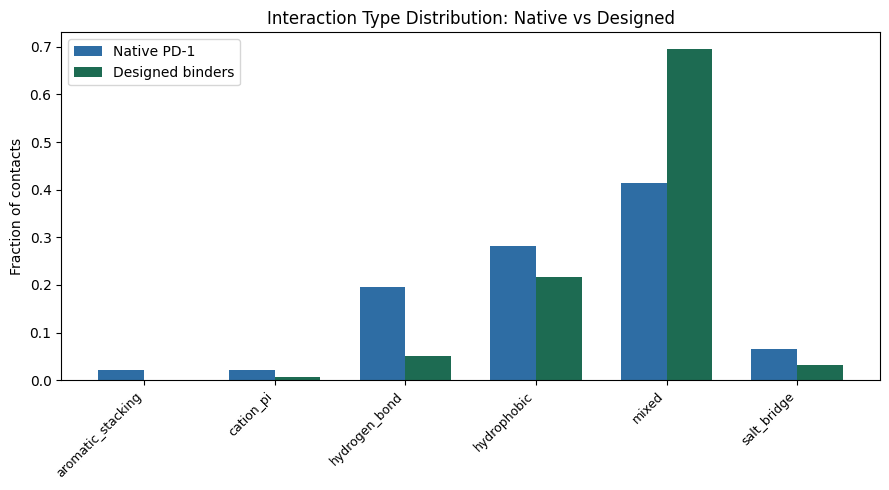

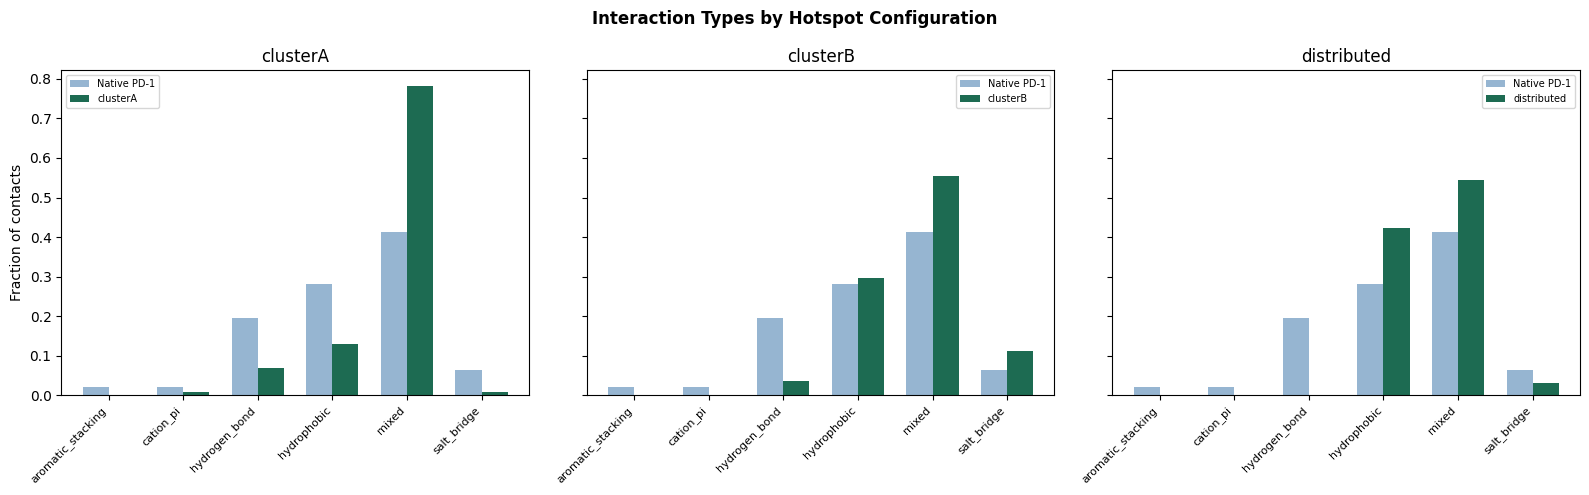

In [11]:
# ============================================================
# Cell 9: Analysis 1 — Interaction type distribution
# ============================================================

print("=== Interaction Type Distribution ===")

native_types = df_native["interaction_type"].value_counts()
print("\nNative PD-1/PD-L1:")
print(native_types.to_string())

if len(df_designs) > 0:
    # Overall comparison: native vs all designs
    design_types = df_designs["interaction_type"].value_counts()
    all_types = sorted(set(native_types.index) | set(design_types.index))

    native_frac = np.array([native_types.get(t, 0) for t in all_types], dtype=float)
    design_frac = np.array([design_types.get(t, 0) for t in all_types], dtype=float)
    native_frac = native_frac / native_frac.sum()
    design_frac = design_frac / design_frac.sum()

    x = np.arange(len(all_types))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x - width/2, native_frac, width, label="Native PD-1", color="#2e6da4")
    ax.bar(x + width/2, design_frac, width, label="Designed binders", color="#1d6b52")
    ax.set_xticks(x)
    ax.set_xticklabels(all_types, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Fraction of contacts")
    ax.set_title("Interaction Type Distribution: Native vs Designed")
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "interaction_type_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

    # NEW: Grouped by hotspot configuration
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
    for ax_i, hs_config in enumerate(['clusterA', 'clusterB', 'distributed']):
        sub = df_designs[df_designs['hotspot_config'] == hs_config]
        if len(sub) == 0:
            axes[ax_i].set_title(f"{hs_config}\n(no data)")
            continue
        sub_types = sub["interaction_type"].value_counts()
        sub_frac = np.array([sub_types.get(t, 0) for t in all_types], dtype=float)
        sub_frac = sub_frac / sub_frac.sum() if sub_frac.sum() > 0 else sub_frac

        axes[ax_i].bar(x - width/2, native_frac, width, label="Native PD-1", color="#2e6da4", alpha=0.5)
        axes[ax_i].bar(x + width/2, sub_frac, width, label=hs_config, color="#1d6b52")
        axes[ax_i].set_xticks(x)
        axes[ax_i].set_xticklabels(all_types, rotation=45, ha="right", fontsize=8)
        axes[ax_i].set_title(f"{hs_config}")
        axes[ax_i].legend(fontsize=7)

    axes[0].set_ylabel("Fraction of contacts")
    plt.suptitle("Interaction Types by Hotspot Configuration", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "interaction_types_by_hotspot_config.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Save per-design interaction fractions
    design_type_matrix = df_designs.groupby(["design", "interaction_type"]).size().unstack(fill_value=0)
    design_type_frac = design_type_matrix.div(design_type_matrix.sum(axis=1), axis=0)
    design_type_frac.to_csv(OUTPUT_DIR / "interaction_type_fraction_by_design.csv")
else:
    print("No design contacts available; skipping.")


=== Hotspot Coverage Analysis ===
 target_resnum target_aa target_class        pd1_residues                      pd1_interactions  n_designs_contacting
            18         ?            ?          no contact                                  none                     1
            20         ?            ?          no contact                                  none                     0
            26         D     negative                S, Q                         hydrogen_bond                     0
            56         Y     aromatic             A, Q, I                    hydrophobic, mixed                     0
           113         R     positive                I, E                    mixed, salt_bridge                     0
           120         G        other                   E                                 mixed                    26
           122         D     negative          N, Y, K, I     hydrogen_bond, mixed, salt_bridge                     4
           123        

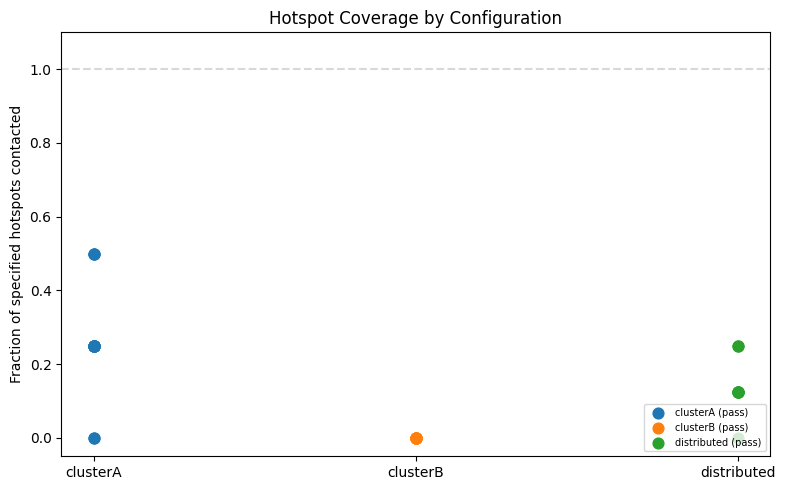


Mean hotspot coverage by config:
                    mean       std  count
hotspot_config                           
clusterA        0.265625  0.143433     16
clusterB        0.000000  0.000000      7
distributed     0.140625  0.080109      8

Mean hotspot coverage by pass/fail:
                         mean       std  count
passes_final_filter                           
True                 0.173387  0.153696     31


In [12]:
# ============================================================
# Cell 10: Analysis 2 — Per-hotspot contact coverage
# ============================================================
# For each design, check: what fraction of the SPECIFIED hotspot residues
# (the ones that were given to RFdiffusion for that condition) were actually
# contacted by the designed binder?

print("=== Hotspot Coverage Analysis ===")

# First, build the global hotspot comparison table (native PD-1 at each position)
hotspot_comparison = []
for hotspot in ALL_HOTSPOTS:
    native_at = df_native[df_native["target_resnum"] == hotspot]
    if len(native_at) > 0:
        target_aa = native_at.iloc[0]["target_resname"]
        target_class = native_at.iloc[0]["target_class"]
        pd1_residues = ", ".join(native_at["binder_resname"].tolist())
        pd1_interactions = ", ".join(sorted(set(native_at["interaction_type"].tolist())))
    else:
        target_aa = "?"
        target_class = "?"
        pd1_residues = "no contact"
        pd1_interactions = "none"

    n_designs = 0
    if len(df_designs) > 0:
        designed_at = df_designs[df_designs["target_resnum"] == hotspot]
        n_designs = designed_at["design"].nunique()

    hotspot_comparison.append({
        "target_resnum": hotspot,
        "target_aa": target_aa,
        "target_class": target_class,
        "pd1_residues": pd1_residues,
        "pd1_interactions": pd1_interactions,
        "n_designs_contacting": n_designs,
    })

df_hotspot = pd.DataFrame(hotspot_comparison)
print(df_hotspot.to_string(index=False))
df_hotspot.to_csv(OUTPUT_DIR / "hotspot_comparison.csv", index=False)

# Now compute per-design hotspot coverage using condition-specific hotspot sets
if len(df_designs) > 0:
    coverage_rows = []
    for design_name in df_designs["design"].unique():
        sub = df_designs[df_designs["design"] == design_name]
        cond_id = sub.iloc[0]["condition_id"]
        hs_config = sub.iloc[0]["hotspot_config"]
        specified_hotspots = set(HOTSPOT_MAP[hs_config])
        contacted_targets = set(sub["target_resnum"].unique())
        covered = specified_hotspots & contacted_targets
        coverage_rows.append({
            "design": design_name,
            "condition_id": cond_id,
            "hotspot_config": hs_config,
            "passes_final_filter": sub.iloc[0]["passes_final_filter"],
            "n_specified": len(specified_hotspots),
            "n_covered": len(covered),
            "coverage_frac": len(covered) / len(specified_hotspots),
            "covered_residues": sorted(covered),
            "missed_residues": sorted(specified_hotspots - covered),
        })

    df_coverage = pd.DataFrame(coverage_rows)
    df_coverage.to_csv(OUTPUT_DIR / "hotspot_coverage_by_design.csv", index=False)

    # Plot: coverage by hotspot config, pass vs fail
    fig, ax = plt.subplots(figsize=(8, 5))
    for hs in ['clusterA', 'clusterB', 'distributed']:
        for pf, marker, alpha in [(True, 'o', 1.0), (False, 'x', 0.5)]:
            sub = df_coverage[(df_coverage['hotspot_config'] == hs) & (df_coverage['passes_final_filter'] == pf)]
            if len(sub) == 0:
                continue
            label = f"{hs} ({'pass' if pf else 'fail'})"
            ax.scatter(
                [hs] * len(sub), sub['coverage_frac'],
                marker=marker, alpha=alpha, s=60, label=label
            )
    ax.set_ylabel("Fraction of specified hotspots contacted")
    ax.set_title("Hotspot Coverage by Configuration")
    ax.set_ylim(-0.05, 1.1)
    ax.legend(fontsize=7, loc='lower right')
    ax.axhline(1.0, color='gray', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "hotspot_coverage_scatter.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Summary
    print("\nMean hotspot coverage by config:")
    print(df_coverage.groupby('hotspot_config')['coverage_frac'].agg(['mean', 'std', 'count']).to_string())
    print("\nMean hotspot coverage by pass/fail:")
    print(df_coverage.groupby('passes_final_filter')['coverage_frac'].agg(['mean', 'std', 'count']).to_string())


=== Binder Residue Likelihood at Each Hotspot ===


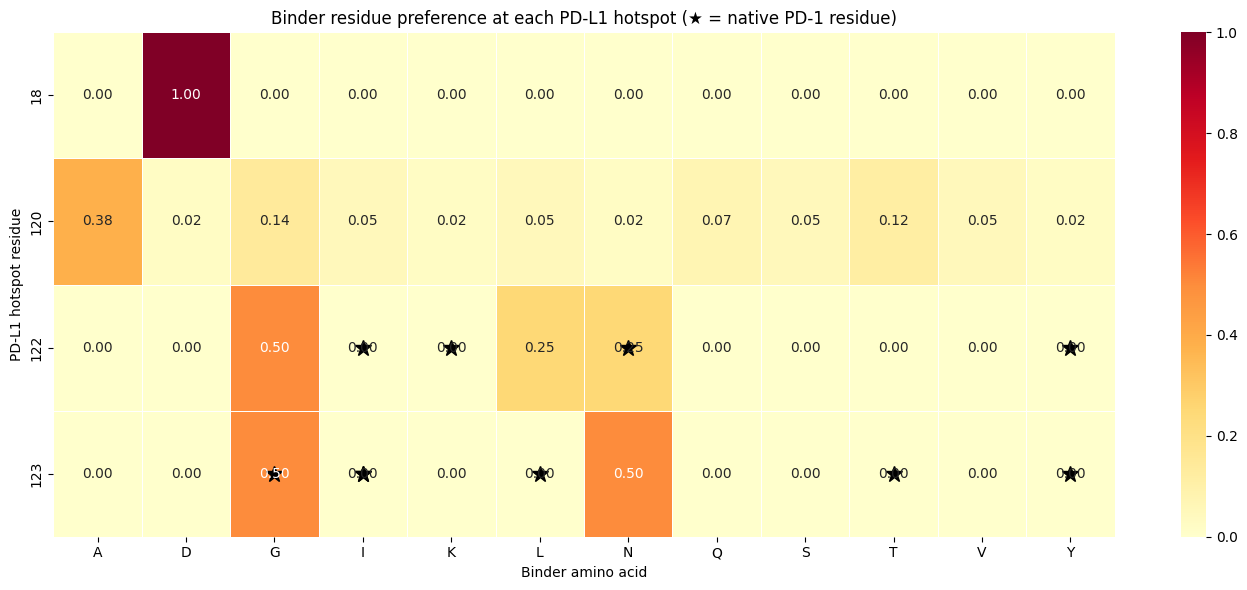

Saved residue likelihood for pass designs (31 designs)


In [13]:
# ============================================================
# Cell 11: Analysis 3 — Residue likelihood heatmap
# ============================================================

if len(df_designs) > 0:
    print("=== Binder Residue Likelihood at Each Hotspot ===")

    amino_acids = sorted("ACDEFGHIKLMNPQRSTVWY")
    likelihood_data = []

    for hotspot in ALL_HOTSPOTS:
        designed_at = df_designs[df_designs["target_resnum"] == hotspot]
        if len(designed_at) == 0:
            continue

        aa_counts = Counter(designed_at["binder_resname"])
        total = sum(aa_counts.values())
        row = {"target_resnum": hotspot}
        for aa in amino_acids:
            row[aa] = aa_counts.get(aa, 0) / total if total > 0 else 0
        likelihood_data.append(row)

    if likelihood_data:
        df_likelihood = pd.DataFrame(likelihood_data).set_index("target_resnum")
        df_likelihood = df_likelihood.loc[:, (df_likelihood != 0).any(axis=0)]

        fig, ax = plt.subplots(figsize=(14, 6))
        sns.heatmap(df_likelihood, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax,
                    linewidths=0.5, linecolor="white", vmin=0, vmax=1)

        # Mark native PD-1 residues with stars
        for i, hotspot in enumerate(df_likelihood.index):
            native_at = df_native[df_native["target_resnum"] == hotspot]
            for _, nr in native_at.iterrows():
                native_aa = nr["binder_resname"]
                if native_aa in df_likelihood.columns:
                    j = list(df_likelihood.columns).index(native_aa)
                    ax.plot(j + 0.5, i + 0.5, "k*", markersize=12, markeredgewidth=1)

        ax.set_title("Binder residue preference at each PD-L1 hotspot (★ = native PD-1 residue)")
        ax.set_xlabel("Binder amino acid")
        ax.set_ylabel("PD-L1 hotspot residue")
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "residue_likelihood_heatmap.png", dpi=150, bbox_inches="tight")
        plt.show()

        # NEW: Split by pass vs fail
        for label, mask in [("pass", df_designs["passes_final_filter"]==True),
                            ("fail", df_designs["passes_final_filter"]==False)]:
            sub = df_designs[mask]
            if len(sub) == 0:
                continue
            ld = []
            for hotspot in ALL_HOTSPOTS:
                dat = sub[sub["target_resnum"] == hotspot]
                if len(dat) == 0: continue
                aa_c = Counter(dat["binder_resname"])
                tot = sum(aa_c.values())
                r = {"target_resnum": hotspot}
                for aa in amino_acids:
                    r[aa] = aa_c.get(aa, 0) / tot if tot > 0 else 0
                ld.append(r)
            if ld:
                df_lk = pd.DataFrame(ld).set_index("target_resnum")
                df_lk = df_lk.loc[:, (df_lk != 0).any(axis=0)]
                df_lk.to_csv(OUTPUT_DIR / f"residue_likelihood_{label}.csv")
                print(f"Saved residue likelihood for {label} designs ({len(sub['design'].unique())} designs)")

        df_likelihood.to_csv(OUTPUT_DIR / "residue_likelihood_matrix.csv")
    else:
        print("No design contacts at hotspot residues; skipping heatmap.")
else:
    print("No design contacts available; skipping heatmap.")


=== PD-1 Mimicry Analysis ===
At each hotspot: does the designed binder use the same residue as PD-1,
a different residue of the same class, or a completely different solution?

Overall mimicry distribution:
mimicry
novel_solution    43
same_class         3
exact_match        2


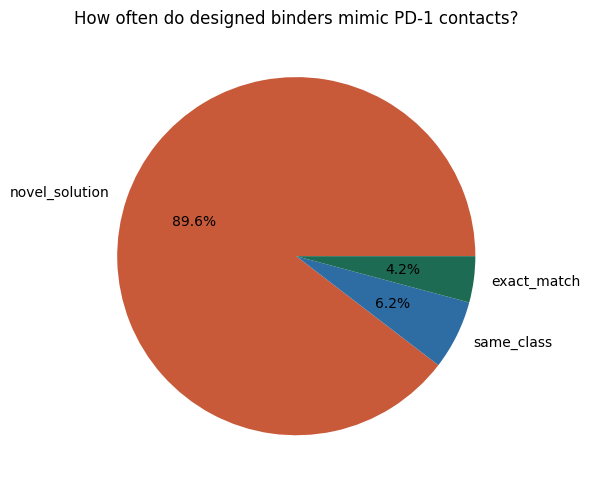

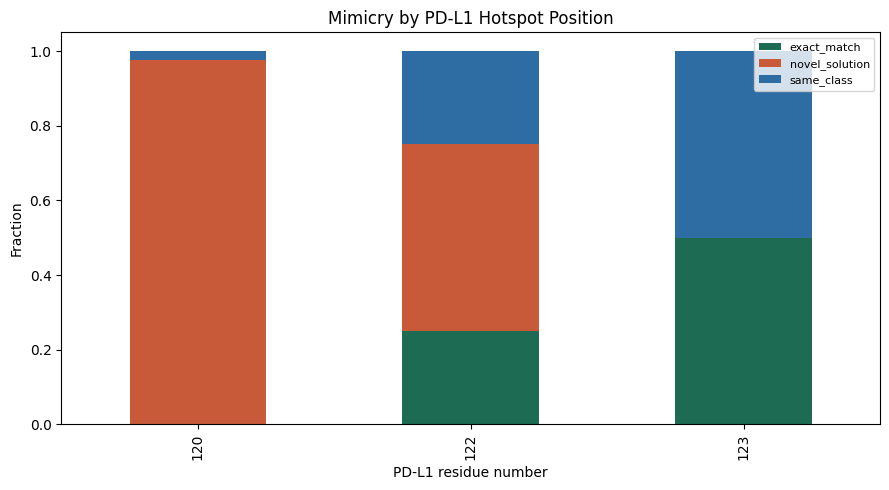

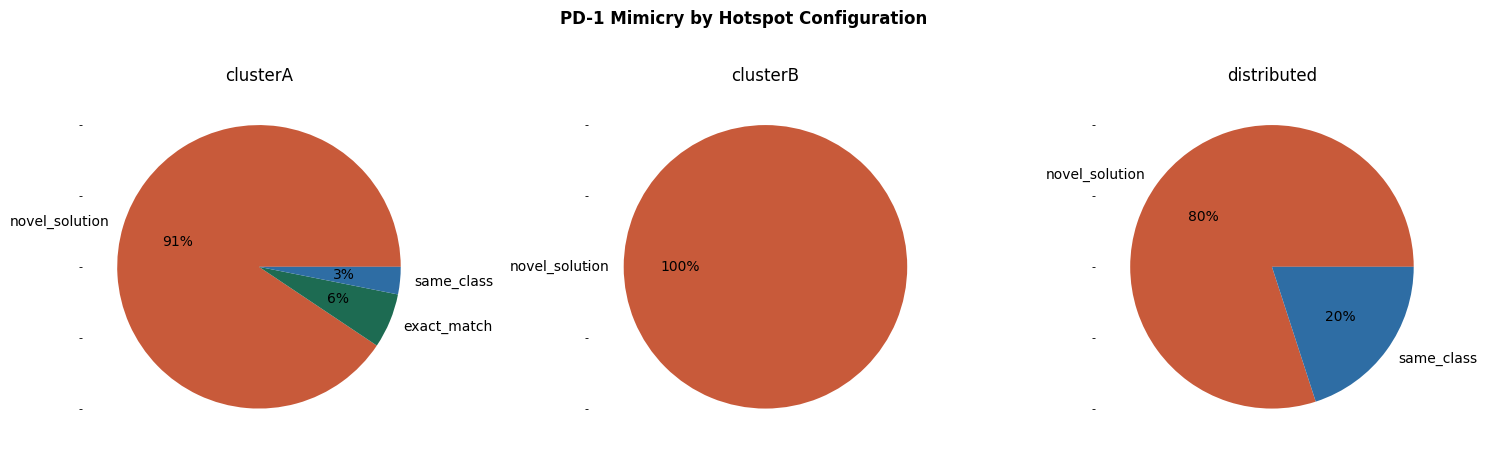

In [14]:
# ============================================================
# Cell 12: Analysis 4 — PD-1 mimicry score
# ============================================================

print("=== PD-1 Mimicry Analysis ===")
print("At each hotspot: does the designed binder use the same residue as PD-1,")
print("a different residue of the same class, or a completely different solution?")

mimicry_results = []

if len(df_designs) > 0:
    for _, row in df_hotspot.iterrows():
        hotspot = row["target_resnum"]
        pd1_aas = set(row["pd1_residues"].split(", ")) if row["pd1_residues"] != "no contact" else set()

        designed_at = df_designs[df_designs["target_resnum"] == hotspot]
        if len(designed_at) == 0 or not pd1_aas:
            continue

        pd1_classes = {classify_residue(pd1_aa) for pd1_aa in pd1_aas}

        for _, d_row in designed_at.iterrows():
            d_aa = d_row["binder_resname"]
            d_class = d_row["binder_class"]

            if d_aa in pd1_aas:
                mimicry = "exact_match"
            elif d_class in pd1_classes:
                mimicry = "same_class"
            else:
                mimicry = "novel_solution"

            mimicry_results.append({
                "target_resnum": hotspot,
                "target_aa": row["target_aa"],
                "pd1_residues": row["pd1_residues"],
                "designed_residue": d_aa,
                "designed_class": d_class,
                "mimicry": mimicry,
                "design": d_row["design"],
                "hotspot_config": d_row["hotspot_config"],
                "passes_final_filter": d_row["passes_final_filter"],
            })

if mimicry_results:
    df_mimicry = pd.DataFrame(mimicry_results)

    mimicry_counts = df_mimicry["mimicry"].value_counts()
    print("\nOverall mimicry distribution:")
    print(mimicry_counts.to_string())

    # Pie chart
    fig, ax = plt.subplots(figsize=(6, 5))
    colors = {"exact_match": "#1d6b52", "same_class": "#2e6da4", "novel_solution": "#c85a3a"}
    mimicry_counts.plot(kind="pie", ax=ax, autopct="%1.1f%%",
                        colors=[colors.get(c, "#ccc") for c in mimicry_counts.index])
    ax.set_ylabel("")
    ax.set_title("How often do designed binders mimic PD-1 contacts?")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "mimicry_pie.png", dpi=150, bbox_inches="tight")
    plt.show()

    # By hotspot position
    mimicry_by_hs = df_mimicry.groupby(["target_resnum", "mimicry"]).size().unstack(fill_value=0)
    mimicry_by_hs_frac = mimicry_by_hs.div(mimicry_by_hs.sum(axis=1), axis=0)
    ax = mimicry_by_hs_frac.plot(kind="bar", stacked=True, figsize=(9, 5),
                                  color=[colors.get(c, "#ccc") for c in mimicry_by_hs_frac.columns])
    ax.set_title("Mimicry by PD-L1 Hotspot Position")
    ax.set_xlabel("PD-L1 residue number")
    ax.set_ylabel("Fraction")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "mimicry_by_hotspot.png", dpi=150, bbox_inches="tight")
    plt.show()

    # NEW: By hotspot configuration
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    for ax_i, hs_config in enumerate(['clusterA', 'clusterB', 'distributed']):
        sub = df_mimicry[df_mimicry['hotspot_config'] == hs_config]
        if len(sub) == 0:
            axes[ax_i].set_title(f"{hs_config}\n(no data)")
            continue
        mc = sub["mimicry"].value_counts()
        mc.plot(kind="pie", ax=axes[ax_i], autopct="%1.0f%%",
                colors=[colors.get(c, "#ccc") for c in mc.index])
        axes[ax_i].set_ylabel("")
        axes[ax_i].set_title(f"{hs_config}")
    plt.suptitle("PD-1 Mimicry by Hotspot Configuration", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "mimicry_by_config.png", dpi=150, bbox_inches="tight")
    plt.show()

    df_mimicry.to_csv(OUTPUT_DIR / "mimicry_analysis.csv", index=False)
else:
    df_mimicry = pd.DataFrame()
    print("No mimicry results generated.")


=== Contact Frequency by PD-L1 Residue ===


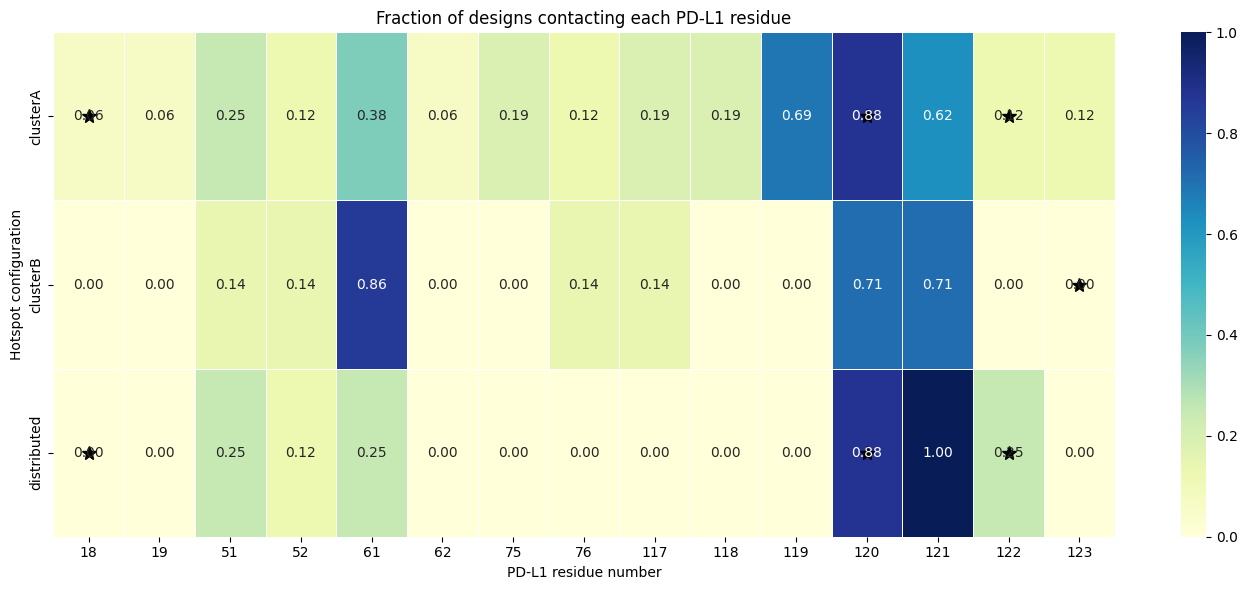

In [15]:
# ============================================================
# Cell 13: Analysis 5 — Contact frequency heatmap per PD-L1 residue
# ============================================================
# Which PD-L1 residues are contacted most frequently?
# Grouped by hotspot configuration.

if len(df_designs) > 0:
    print("=== Contact Frequency by PD-L1 Residue ===")

    # For each hotspot config, compute: how many designs contact each PD-L1 residue?
    contact_freq = {}
    for hs_config in ['clusterA', 'clusterB', 'distributed']:
        sub = df_designs[df_designs['hotspot_config'] == hs_config]
        if len(sub) == 0:
            continue
        n_designs = sub['design'].nunique()
        freq = sub.groupby('target_resnum')['design'].nunique() / n_designs
        contact_freq[hs_config] = freq

    if contact_freq:
        df_freq = pd.DataFrame(contact_freq).fillna(0)
        df_freq = df_freq.sort_index()

        fig, ax = plt.subplots(figsize=(14, 6))
        sns.heatmap(df_freq.T, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax,
                    linewidths=0.5, linecolor="white", vmin=0, vmax=1)
        ax.set_xlabel("PD-L1 residue number")
        ax.set_ylabel("Hotspot configuration")
        ax.set_title("Fraction of designs contacting each PD-L1 residue")

        # Mark the specified hotspot residues
        for i, hs in enumerate(df_freq.columns):
            if hs in ['clusterA', 'clusterB', 'distributed']:
                for j, resnum in enumerate(df_freq.index):
                    if resnum in HOTSPOT_MAP.get(hs, []):
                        ax.plot(j + 0.5, i + 0.5, "k*", markersize=10)

        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "contact_frequency_heatmap.png", dpi=150, bbox_inches="tight")
        plt.show()

        df_freq.to_csv(OUTPUT_DIR / "contact_frequency_by_config.csv")
else:
    print("No design contacts available.")


In [16]:
# ============================================================
# Cell 14: Export structured JSON for portfolio page
# ============================================================
# This JSON feeds the interactive fingerprinting section of the Part II
# portfolio page.

portfolio_data = {}

# 1. Contact frequency by PD-L1 residue per hotspot config
if len(df_designs) > 0:
    freq_data = {}
    for hs in ['clusterA', 'clusterB', 'distributed']:
        sub = df_designs[df_designs['hotspot_config'] == hs]
        if len(sub) == 0: continue
        n_d = sub['design'].nunique()
        freq = sub.groupby('target_resnum')['design'].nunique()
        freq_data[hs] = {int(k): round(v/n_d, 3) for k, v in freq.items()}
    portfolio_data['contact_frequency'] = freq_data

# 2. Mimicry summary by config
if len(df_mimicry) > 0:
    mim_summary = {}
    for hs in ['clusterA', 'clusterB', 'distributed']:
        sub = df_mimicry[df_mimicry['hotspot_config'] == hs]
        if len(sub) == 0: continue
        counts = sub['mimicry'].value_counts().to_dict()
        mim_summary[hs] = counts
    portfolio_data['mimicry_by_config'] = mim_summary

# 3. Hotspot coverage summary
if 'df_coverage' in dir() and len(df_coverage) > 0:
    cov_summary = df_coverage.groupby('hotspot_config')['coverage_frac'].agg(['mean','std']).round(3)
    portfolio_data['hotspot_coverage'] = cov_summary.to_dict(orient='index')

# 4. Interaction type fractions per config
if len(df_designs) > 0:
    int_data = {}
    for hs in ['clusterA', 'clusterB', 'distributed']:
        sub = df_designs[df_designs['hotspot_config'] == hs]
        if len(sub) == 0: continue
        counts = sub['interaction_type'].value_counts()
        total = counts.sum()
        int_data[hs] = {k: round(v/total, 3) for k, v in counts.items()}
    portfolio_data['interaction_types'] = int_data

# Native reference
native_int = df_native['interaction_type'].value_counts()
native_total = native_int.sum()
portfolio_data['native_interaction_types'] = {k: round(v/native_total, 3) for k, v in native_int.items()}

json_path = OUTPUT_DIR / "fingerprint_summary.json"
with open(json_path, 'w') as f:
    json.dump(portfolio_data, f, indent=2)

print(f"Portfolio JSON saved to {json_path}")
print(f"Keys: {list(portfolio_data.keys())}")


Portfolio JSON saved to /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/fingerprinting_param_sensitivity/fingerprint_summary.json
Keys: ['contact_frequency', 'mimicry_by_config', 'hotspot_coverage', 'interaction_types', 'native_interaction_types']


In [17]:
# ============================================================
# Cell 15: Full-sidechain interaction fingerprinting — CLEAN
# ============================================================
# WHAT THIS CELL DOES:
#   Repeats the interaction fingerprinting on full-sidechain binder models by
#   superimposing each ESMFold-predicted binder onto the RFdiffusion docked
#   complex backbone via Cα alignment, then measuring heavy-atom contacts.
#
# CLEAN-UP RELATIVE TO PRIOR VERSION:
#   - Uses HOTSPOT_MAP from Cell 3 only. No local HOTSPOT_CONFIGS allowed.
#   - Derives native PD-1 contact residues from df_native instead of a hand-coded
#     native-contact map.
#   - Stores the closest atom pair for each residue-pair contact.
#   - Uses explicitly named full-sidechain dataframes, while preserving short
#     aliases for downstream cells.
#   - Adds provenance to the exported JSON.
# ============================================================

import json
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd

from Bio.PDB import PDBParser, Superimposer
from Bio.PDB.NeighborSearch import NeighborSearch
from Bio.PDB.Polypeptide import is_aa
from Bio.Data.IUPACData import protein_letters_3to1

CONTACT_CUTOFF = 4.5  # Angstroms, heavy-atom distance

# Guard: full-sidechain analysis must use the same hotspots as the RFdiffusion run.
assert HOTSPOT_MAP == HOTSPOT_MAP_AUTHORITATIVE == EXPECTED_HOTSPOT_MAP, (
    "Authoritative hotspots have changed. Stop and verify Cell 3."
)

# Portfolio data directory containing ESMFold binder PDBs and manifest.
VIEWER_DIR = (
    PROJECT_DIR
    / "portfolio_pages"
    / "Page3_interaction_fingerprinting"
    / "portfolio_page3-viewer_structures"
    / "passed_31"
)

# Portfolio-facing output directory. Keep OUTPUT_DIR alias so existing later cells work.
PORTFOLIO_OUTPUT_DIR = (
    PROJECT_DIR
    / "portfolio_pages"
    / "Page3_interaction_fingerprinting"
    / "fingerprinting_results"
)
PORTFOLIO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = PORTFOLIO_OUTPUT_DIR

print(f"PROJECT_DIR: {PROJECT_DIR}")
print(f"STUDY_DIR exists: {STUDY_DIR.exists()}")
print(f"VIEWER_DIR exists: {VIEWER_DIR.exists()}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

# Residue physicochemistry classification for portfolio-level fingerprints.
# This deliberately collapses positive/negative into charged for the summary plots.
RESIDUE_CLASS_FULL_SIDECHAIN = {
    "A": "hydrophobic", "V": "hydrophobic", "L": "hydrophobic", "I": "hydrophobic",
    "M": "hydrophobic", "P": "hydrophobic", "G": "hydrophobic",
    "F": "aromatic", "W": "aromatic", "Y": "aromatic",
    "S": "polar", "T": "polar", "N": "polar", "Q": "polar", "C": "polar",
    "D": "charged", "E": "charged", "K": "charged", "R": "charged", "H": "charged",
}

def classify_residue_full_sidechain(aa_one_letter):
    return RESIDUE_CLASS_FULL_SIDECHAIN.get(str(aa_one_letter).upper(), "unknown")

def classify_interaction_full_sidechain(class_a, class_b):
    pair = frozenset([class_a, class_b])
    if pair == frozenset(["charged"]):
        return "salt_bridge_compatible"
    if pair == frozenset(["charged", "polar"]):
        return "hbond_compatible"
    if pair == frozenset(["polar"]):
        return "hbond_compatible"
    if pair <= frozenset(["hydrophobic", "aromatic"]):
        return "hydrophobic_or_aromatic"
    return "mixed"

def three_to_one_safe_local(resname):
    key = str(resname).capitalize()
    return protein_letters_3to1.get(key, "X")

# Load manifest and locate source PDBs.
manifest_path_json = VIEWER_DIR / "manifest.json"
manifest_path_csv = VIEWER_DIR / "manifest.csv"
if manifest_path_json.exists():
    with open(manifest_path_json) as f:
        manifest_data = json.load(f)
elif manifest_path_csv.exists():
    manifest_data = pd.read_csv(manifest_path_csv).to_dict("records")
else:
    raise FileNotFoundError(f"Could not find manifest.json or manifest.csv in {VIEWER_DIR}")

print(f"Loaded manifest: {len(manifest_data)} designs")

parser = PDBParser(QUIET=True)


def superimpose_esmfold_onto_complex(esmfold_pdb, complex_pdb, binder_chain_complex="B"):
    """
    Superimpose the ESMFold binder (full sidechains) onto the binder backbone
    in the RFdiffusion complex pose. Returns the superimposed ESMFold model,
    ESMFold chain, complex model, and alignment RMSD.
    """
    complex_struct = parser.get_structure("complex", str(complex_pdb))
    esmfold_struct = parser.get_structure("esmfold", str(esmfold_pdb))

    complex_model = complex_struct[0]
    esmfold_model = esmfold_struct[0]

    complex_binder = complex_model[binder_chain_complex]
    complex_cas = [
        res["CA"]
        for res in complex_binder.get_residues()
        if res.id[0] == " " and "CA" in res
    ]

    esmfold_chain = list(esmfold_model.get_chains())[0]
    esmfold_cas = [
        res["CA"]
        for res in esmfold_chain.get_residues()
        if res.id[0] == " " and "CA" in res
    ]

    n = min(len(complex_cas), len(esmfold_cas))
    if n == 0:
        raise ValueError("No CA atoms found for alignment")

    if len(complex_cas) != len(esmfold_cas):
        warnings.warn(
            f"CA count mismatch: complex={len(complex_cas)}, "
            f"esmfold={len(esmfold_cas)}. Aligning first {n}."
        )

    sup = Superimposer()
    sup.set_atoms(complex_cas[:n], esmfold_cas[:n])
    sup.apply(esmfold_model.get_atoms())

    return esmfold_model, esmfold_chain, complex_model, sup.rms


def extract_contacts_full_sidechain(
    esmfold_chain,
    complex_model,
    target_chain_id="A",
    binder_sequence=None,
    cutoff=CONTACT_CUTOFF,
):
    """
    Extract residue-level binder–target contacts using full heavy atoms.

    A residue pair is counted once if any heavy-atom pair is within cutoff.
    The stored distance/atom labels correspond to the closest atom pair for
    that residue pair, not the first pair encountered.
    """
    target_chain = complex_model[target_chain_id]

    target_atoms = []
    for res in target_chain.get_residues():
        if res.id[0] != " " or not is_aa(res, standard=True):
            continue
        for atom in res.get_atoms():
            if atom.element == "H":
                continue
            target_atoms.append(atom)

    ns = NeighborSearch(target_atoms)

    binder_residues = [
        res
        for res in esmfold_chain.get_residues()
        if res.id[0] == " " and is_aa(res, standard=True)
    ]

    if binder_sequence is not None:
        binder_sequence = str(binder_sequence).strip().upper()

    contact_by_pair = {}

    for i, b_res in enumerate(binder_residues):
        b_resnum = int(b_res.id[1])
        if binder_sequence and i < len(binder_sequence):
            b_aa = binder_sequence[i]
        else:
            b_aa = three_to_one_safe_local(b_res.get_resname())
        b_class = classify_residue_full_sidechain(b_aa)

        for b_atom in b_res.get_atoms():
            if b_atom.element == "H":
                continue

            for t_atom in ns.search(b_atom.get_coord(), cutoff):
                t_res = t_atom.get_parent()
                if t_res.id[0] != " " or not is_aa(t_res, standard=True):
                    continue

                t_resnum = int(t_res.id[1])
                t_aa = three_to_one_safe_local(t_res.get_resname())
                t_class = classify_residue_full_sidechain(t_aa)
                dist = float(b_atom - t_atom)
                pair_key = (b_resnum, t_resnum)

                record = {
                    "binder_resnum": b_resnum,
                    "binder_aa": b_aa,
                    "binder_class": b_class,
                    "target_resnum": t_resnum,
                    "target_aa": t_aa,
                    "target_class": t_class,
                    "interaction_type": classify_interaction_full_sidechain(b_class, t_class),
                    "distance": round(dist, 3),
                    "binder_atom": b_atom.get_name(),
                    "target_atom": t_atom.get_name(),
                }

                if pair_key not in contact_by_pair or dist < contact_by_pair[pair_key]["distance"]:
                    contact_by_pair[pair_key] = record

    return list(contact_by_pair.values())


def resolve_esmfold_pdb(entry):
    """Resolve the ESMFold binder PDB from manifest fields."""
    candidate_names = []
    for key in ["esmfold_pdb_file", "esmfold_file", "pdb_file"]:
        val = entry.get(key)
        if val and str(val).lower() not in {"nan", "none", ""}:
            candidate_names.append(str(val))

    # If the manifest's pdb_file points to a threaded complex, infer the matching ESMFold file.
    inferred = []
    for name in candidate_names:
        inferred.append(name)
        if "__threaded_complex.pdb" in name:
            inferred.append(name.replace("__threaded_complex.pdb", "__esmfold_binder.pdb"))

    for name in inferred:
        p = VIEWER_DIR / name
        if p.exists():
            return p
    return None


def resolve_complex_pdb(entry):
    """Resolve the RFdiffusion complex pose PDB."""
    complex_src = entry.get("source_designed_pdb")
    if complex_src and str(complex_src).lower() not in {"nan", "none", ""}:
        p = Path(complex_src)
        if p.exists():
            return p

    condition_id = entry["condition_id"]
    seq_id = entry["seq_id"]
    base_design = seq_id.split("_rank")[0] if "_rank" in seq_id else seq_id
    p = STUDY_DIR / condition_id / "rfdiffusion_outputs" / f"{base_design}.pdb"
    if p.exists():
        return p
    return None


# Derive native PD-1 residues that contact each PD-L1 target residue from df_native.
# This replaces the previous hand-coded native-contact map.
NATIVE_CONTACTS_BY_TARGET = defaultdict(list)
if "df_native" not in globals() or len(df_native) == 0:
    raise RuntimeError("df_native is missing. Run the native PD-1/PD-L1 contact extraction cell first.")

for _, row in df_native.iterrows():
    target_resnum = int(row["target_resnum"])
    binder_aa = row["binder_resname"]
    binder_class = classify_residue_full_sidechain(binder_aa)
    NATIVE_CONTACTS_BY_TARGET[target_resnum].append({
        "pd1_residue": binder_aa,
        "pd1_resnum": int(row["binder_resnum"]),
        "pd1_class": binder_class,
    })

# Run the analysis across all designs in the viewer manifest.
all_contacts_full_sidechain = []
alignment_results = []
full_sidechain_errors = []

for entry in manifest_data:
    rank = int(entry["rank"])
    condition_id = entry["condition_id"]
    seq_id = entry["seq_id"]
    binder_sequence = entry.get("binder_sequence")
    hotspot_config = entry.get("hotspot_config") or parse_condition(condition_id)[1]
    length = entry.get("length") or parse_condition(condition_id)[0]
    noise = entry.get("noise") if entry.get("noise") is not None else parse_condition(condition_id)[2]

    esmfold_pdb = resolve_esmfold_pdb(entry)
    complex_pdb = resolve_complex_pdb(entry)

    if esmfold_pdb is None:
        full_sidechain_errors.append((rank, condition_id, "ESMFold PDB not found"))
        print(f"  Rank {rank}: ESMFold PDB not found")
        continue
    if complex_pdb is None:
        full_sidechain_errors.append((rank, condition_id, "RFdiffusion complex PDB not found"))
        print(f"  Rank {rank}: RFdiffusion complex not found")
        continue

    try:
        esmfold_model, esmfold_chain, complex_model, align_rmsd = superimpose_esmfold_onto_complex(
            esmfold_pdb, complex_pdb
        )
        contacts = extract_contacts_full_sidechain(
            esmfold_chain,
            complex_model,
            binder_sequence=binder_sequence,
            cutoff=CONTACT_CUTOFF,
        )

        alignment_results.append({
            "rank": rank,
            "condition_id": condition_id,
            "seq_id": seq_id,
            "hotspot_config": hotspot_config,
            "length": int(length),
            "noise": float(noise),
            "alignment_rmsd": round(float(align_rmsd), 3),
            "n_contacts": len(contacts),
        })

        for c in contacts:
            c.update({
                "rank": rank,
                "condition_id": condition_id,
                "seq_id": seq_id,
                "hotspot_config": hotspot_config,
                "length": int(length),
                "noise": float(noise),
            })

        all_contacts_full_sidechain.extend(contacts)
        if rank <= 5:
            print(f"  ✓ Rank {rank} ({condition_id}): RMSD={align_rmsd:.2f} Å, {len(contacts)} contacts")

    except Exception as e:
        full_sidechain_errors.append((rank, condition_id, str(e)))
        print(f"  ✗ Rank {rank} ({condition_id}): {e}")

print("\n=== Full-sidechain contact extraction ===")
print(f"  Designs analyzed: {len(alignment_results)}")
print(f"  Total contacts: {len(all_contacts_full_sidechain)}")
print(f"  Errors: {len(full_sidechain_errors)}")

df_contacts_full_sidechain = pd.DataFrame(all_contacts_full_sidechain)
df_align_full_sidechain = pd.DataFrame(alignment_results)

# Preserve aliases for later cells and legacy plotting code.
df_contacts = df_contacts_full_sidechain
df_align = df_align_full_sidechain

if len(df_contacts_full_sidechain) == 0:
    raise RuntimeError("No full-sidechain contacts found. Check manifest/PDB paths and chain IDs.")

# Analysis 1: Contact frequency by PD-L1 residue.
print("\n=== Contact frequency by PD-L1 residue (full sidechain) ===")
contact_freq_full_sidechain = {}
for config in ["clusterA", "clusterB", "distributed"]:
    config_designs = df_align_full_sidechain[df_align_full_sidechain["hotspot_config"] == config]
    n_designs = len(config_designs)
    if n_designs == 0:
        continue

    config_contacts = df_contacts_full_sidechain[df_contacts_full_sidechain["hotspot_config"] == config]
    freq = {}
    for resnum in sorted(config_contacts["target_resnum"].unique()):
        n_contacting = config_contacts[config_contacts["target_resnum"] == resnum]["rank"].nunique()
        freq[int(resnum)] = round(n_contacting / n_designs * 100, 1)

    contact_freq_full_sidechain[config] = freq
    print(f"\n  {config} ({n_designs} designs):")
    for resnum in sorted(freq, key=lambda r: freq[r], reverse=True)[:10]:
        hotspot_marker = " ★" if resnum in HOTSPOT_MAP.get(config, []) else ""
        print(f"    Res {resnum}: {freq[resnum]:.1f}%{hotspot_marker}")

# Analysis 2: Hotspot coverage using authoritative hotspots.
print("\n=== Hotspot coverage (full sidechain; authoritative hotspots) ===")
coverage_by_config_full_sidechain = {}
coverage_per_design_full_sidechain = []

for config in ["clusterA", "clusterB", "distributed"]:
    hotspot_residues = set(HOTSPOT_MAP[config])
    config_designs = df_align_full_sidechain[df_align_full_sidechain["hotspot_config"] == config]
    coverages = []

    for _, design_row in config_designs.iterrows():
        rank = int(design_row["rank"])
        design_contacts = df_contacts_full_sidechain[df_contacts_full_sidechain["rank"] == rank]
        contacted_targets = set(design_contacts["target_resnum"].astype(int))
        covered = sorted(hotspot_residues & contacted_targets)
        missed = sorted(hotspot_residues - contacted_targets)
        coverage = 100 * len(covered) / len(hotspot_residues)
        coverages.append(coverage)

        coverage_per_design_full_sidechain.append({
            "rank": rank,
            "condition_id": design_row["condition_id"],
            "hotspot_config": config,
            "n_hotspots": len(hotspot_residues),
            "n_covered": len(covered),
            "coverage_pct": round(coverage, 1),
            "covered_residues": covered,
            "missed_residues": missed,
        })

    mean_cov = float(np.mean(coverages)) if coverages else 0.0
    std_cov = float(np.std(coverages)) if coverages else 0.0
    coverage_by_config_full_sidechain[config] = {
        "mean": round(mean_cov, 1),
        "std": round(std_cov, 1),
        "n_designs": len(coverages),
    }
    print(f"  {config}: {mean_cov:.1f}% ± {std_cov:.1f}% (n={len(coverages)})")

df_coverage_full_sidechain = pd.DataFrame(coverage_per_design_full_sidechain)
df_coverage = df_coverage_full_sidechain

# Analysis 3: PD-1 mimicry at authoritative hotspot positions.
print("\n=== PD-1 mimicry at hotspot positions (full sidechain; authoritative hotspots) ===")
mimicry_results_full_sidechain = []

for _, contact in df_contacts_full_sidechain.iterrows():
    t_resnum = int(contact["target_resnum"])
    config = contact["hotspot_config"]
    if config not in HOTSPOT_MAP or t_resnum not in HOTSPOT_MAP[config]:
        continue

    native_contacts = NATIVE_CONTACTS_BY_TARGET.get(t_resnum, [])
    if not native_contacts:
        continue

    b_aa = contact["binder_aa"]
    b_class = contact["binder_class"]
    native_aas = {n["pd1_residue"] for n in native_contacts}
    native_classes = {n["pd1_class"] for n in native_contacts}

    if b_aa in native_aas:
        mimicry = "exact_match"
    elif b_class in native_classes:
        mimicry = "same_class"
    else:
        mimicry = "novel"

    mimicry_results_full_sidechain.append({
        "rank": int(contact["rank"]),
        "condition_id": contact["condition_id"],
        "hotspot_config": config,
        "target_resnum": t_resnum,
        "binder_aa": b_aa,
        "binder_class": b_class,
        "native_pd1_aas": ",".join(sorted(native_aas)),
        "native_pd1_classes": ",".join(sorted(native_classes)),
        "mimicry": mimicry,
    })

df_mimicry_full_sidechain = pd.DataFrame(mimicry_results_full_sidechain)
df_mimicry = df_mimicry_full_sidechain

if len(df_mimicry_full_sidechain) > 0:
    overall = df_mimicry_full_sidechain["mimicry"].value_counts()
    total = len(df_mimicry_full_sidechain)
    print(f"  Total contacts at hotspot positions with native PD-1 comparator: {total}")
    for cat in ["exact_match", "same_class", "novel"]:
        n = int(overall.get(cat, 0))
        print(f"    {cat}: {n} ({n/total*100:.1f}%)")

    print("\n  By config:")
    for config in ["clusterA", "clusterB", "distributed"]:
        config_mim = df_mimicry_full_sidechain[df_mimicry_full_sidechain["hotspot_config"] == config]
        if len(config_mim) == 0:
            print(f"    {config}: no hotspot contacts with native comparator")
            continue
        counts = config_mim["mimicry"].value_counts()
        total_c = len(config_mim)
        print(f"    {config} ({total_c} contacts):")
        for cat in ["exact_match", "same_class", "novel"]:
            n = int(counts.get(cat, 0))
            print(f"      {cat}: {n} ({n/total_c*100:.1f}%)")
else:
    print("  No hotspot contacts had a native PD-1 comparator.")

# Analysis 4: Chemical compatibility categories across all contacts.
print("\n=== Interaction type distribution (full sidechain) ===")
int_types_by_config_full_sidechain = {}
for config in ["clusterA", "clusterB", "distributed"]:
    config_contacts = df_contacts_full_sidechain[df_contacts_full_sidechain["hotspot_config"] == config]
    if len(config_contacts) == 0:
        continue
    counts = config_contacts["interaction_type"].value_counts()
    total = len(config_contacts)
    dist = {itype: round(n / total * 100, 1) for itype, n in counts.items()}
    int_types_by_config_full_sidechain[config] = dist

    print(f"\n  {config} ({total} contacts):")
    for itype in ["hydrophobic_or_aromatic", "hbond_compatible", "salt_bridge_compatible", "mixed"]:
        print(f"    {itype}: {dist.get(itype, 0):.1f}%")

# Native PD-1 interaction types computed with the same simplified categories.
if len(df_native) > 0:
    native_type_rows = []
    for _, row in df_native.iterrows():
        b_class = classify_residue_full_sidechain(row["binder_resname"])
        t_class = classify_residue_full_sidechain(row["target_resname"])
        native_type_rows.append(classify_interaction_full_sidechain(b_class, t_class))
    native_counts = pd.Series(native_type_rows).value_counts(normalize=True) * 100
    native_types_full_sidechain = {
        k: round(float(native_counts.get(k, 0.0)), 1)
        for k in ["hydrophobic_or_aromatic", "hbond_compatible", "salt_bridge_compatible", "mixed"]
    }
else:
    native_types_full_sidechain = {}

print("\n  Native PD-1/PD-L1 reference, same simplified categories:")
for itype, pct in native_types_full_sidechain.items():
    print(f"    {itype}: {pct:.1f}%")

# Backbone-only coverage comparison if available from earlier analysis.
backbone_coverage = {}
if "portfolio_data" in globals():
    backbone_coverage = portfolio_data.get("hotspot_coverage", {})

# Fallback to earlier values only if the prior export object is unavailable.
# These are clearly labelled as legacy notebook values.
legacy_backbone_coverage = {"clusterA": 26.6, "clusterB": 0.0, "distributed": 14.1}
if not backbone_coverage:
    backbone_coverage = legacy_backbone_coverage

print("\n=== Comparison: backbone-only vs full-sidechain hotspot coverage ===")
for config in ["clusterA", "clusterB", "distributed"]:
    bb_val = backbone_coverage.get(config, {}).get("mean", backbone_coverage.get(config, 0))
    fs_val = coverage_by_config_full_sidechain.get(config, {}).get("mean", 0)
    delta = fs_val - bb_val
    arrow = "↑" if delta > 0 else "↓" if delta < 0 else "="
    print(f"  {config}: {bb_val:.1f}% → {fs_val:.1f}% ({arrow} {abs(delta):.1f} pp)")

summary_full_sidechain = {
    "analysis_type": "full_sidechain",
    "provenance": {
        "hotspot_source": "06_param_sensitivity_runner.ipynb / conditions.csv",
        "hotspot_map": HOTSPOT_MAP,
        "contact_definition": (
            "Residue pair counted if any heavy atom pair is within 4.5 Å; "
            "closest atom pair retained for distance/atom labels."
        ),
        "representation": "ESMFold binder full sidechains superimposed onto RFdiffusion complex by Cα alignment",
        "native_mimicry_source": "Native PD-1/PD-L1 contacts derived from df_native / PDB 4ZQK",
    },
    "contact_cutoff_angstroms": CONTACT_CUTOFF,
    "n_designs_analyzed": len(alignment_results),
    "total_contacts": len(all_contacts_full_sidechain),
    "alignment_rmsds": {
        r["condition_id"] + "__" + r["seq_id"]: r["alignment_rmsd"]
        for r in alignment_results
    },
    "contact_frequency": contact_freq_full_sidechain,
    "hotspot_coverage": coverage_by_config_full_sidechain,
    "hotspot_coverage_per_design": coverage_per_design_full_sidechain,
    "mimicry_summary": {
        "total_hotspot_contacts": len(df_mimicry_full_sidechain),
        "overall": (
            df_mimicry_full_sidechain["mimicry"].value_counts().to_dict()
            if len(df_mimicry_full_sidechain) > 0 else {}
        ),
        "by_config": {
            config: (
                df_mimicry_full_sidechain[df_mimicry_full_sidechain["hotspot_config"] == config]["mimicry"]
                .value_counts().to_dict()
            )
            for config in ["clusterA", "clusterB", "distributed"]
            if len(df_mimicry_full_sidechain[df_mimicry_full_sidechain["hotspot_config"] == config]) > 0
        },
    },
    "interaction_types": int_types_by_config_full_sidechain,
    "native_interaction_types": native_types_full_sidechain,
    "comparison_to_backbone_only": {
        "backbone_coverage": backbone_coverage,
        "full_sidechain_coverage": {
            config: coverage_by_config_full_sidechain.get(config, {}).get("mean", 0)
            for config in ["clusterA", "clusterB", "distributed"]
        },
    },
}

# Safer JSON write: write locally first, then copy to Drive
import shutil
from pathlib import Path

local_out = Path("/content/fingerprint_summary_full_sidechain.json")
drive_out = OUTPUT_DIR / "fingerprint_summary_full_sidechain.json"

with open(local_out, "w") as f:
    json.dump(summary_full_sidechain, f, indent=2)

print(f"✓ Saved local copy: {local_out}")

try:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    shutil.copy2(local_out, drive_out)
    print(f"✓ Copied to Drive: {drive_out}")
except Exception as e:
    print(f"⚠ Could not copy to Drive: {e}")
    print(f"Local copy is still available at: {local_out}")

contacts_path = OUTPUT_DIR / "contacts_full_sidechain.csv"
df_contacts_full_sidechain.to_csv(contacts_path, index=False)
print(f"✓ Saved: {contacts_path}")

align_path = OUTPUT_DIR / "alignment_full_sidechain.csv"
df_align_full_sidechain.to_csv(align_path, index=False)
print(f"✓ Saved: {align_path}")

coverage_path = OUTPUT_DIR / "hotspot_coverage_full_sidechain.csv"
df_coverage_full_sidechain.to_csv(coverage_path, index=False)
print(f"✓ Saved: {coverage_path}")

if len(df_mimicry_full_sidechain) > 0:
    mimicry_path = OUTPUT_DIR / "mimicry_full_sidechain.csv"
    df_mimicry_full_sidechain.to_csv(mimicry_path, index=False)
    print(f"✓ Saved: {mimicry_path}")

print("\n=== Full-sidechain fingerprinting done. ===")


PROJECT_DIR: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design
STUDY_DIR exists: True
VIEWER_DIR exists: True
OUTPUT_DIR: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/portfolio_pages/Page3_interaction_fingerprinting/fingerprinting_results
Loaded manifest: 31 designs
  ✓ Rank 1 (len70_clusterA_noise05): RMSD=0.24 Å, 14 contacts
  ✓ Rank 2 (len70_distributed_noise0): RMSD=0.33 Å, 22 contacts
  ✓ Rank 3 (len25_clusterA_noise0): RMSD=0.41 Å, 13 contacts
  ✓ Rank 4 (len70_clusterB_noise0): RMSD=0.44 Å, 24 contacts
  ✓ Rank 5 (len70_clusterA_noise0): RMSD=0.45 Å, 18 contacts

=== Full-sidechain contact extraction ===
  Designs analyzed: 31
  Total contacts: 499
  Errors: 0

=== Contact frequency by PD-L1 residue (full sidechain) ===

  clusterA (16 designs):
    Res 120: 93.8% ★
    Res 121: 93.8%
    Res 119: 87.5%
    Res 118: 56.2%
    Res 61: 50.0%
    Res 117: 50.0%
    Res 122: 50.0% ★
    Res 123: 50.0%
    Res 19: 43.8%
    Res 52: 43.8%

  clusterB (7 desi

In [18]:
# ============================================================
# Cell 16: Buried surface area (BSA) at the binder–target interface
# ============================================================
#
# DEPENDENCIES:
#   - Cell 0: Install dependencies (biopython ≥ 1.80)
#   - Cell 1: Project paths
#   - Cell 15: Superimposed ESMFold-on-complex structures
#              (or any cell that produces two-chain full-atom complexes)
#
# COMPUTE:
#   - Runtime: CPU only, ~1–2 min for 31 designs
#   - RAM: < 1 GB
#   - GPU: not required
#   - Colab tier: free tier sufficient
#
# WHAT THIS CELL DOES:
#   Computes buried surface area (BSA) for each binder–target complex:
#     BSA = SASA(binder alone) + SASA(target alone) - SASA(complex)
#   Uses the Shrake-Rupley algorithm (BioPython) with 1.4 Å probe radius.
#   BSA is the standard metric for interface size in structural biology.
#   Typical protein–protein interfaces bury 1,200–2,000 Å².
#
# SCAFFOLD-AGNOSTIC:
#   Works for helical binders, VHH CDR loops, or any two-chain complex.
#   Only requires chain A = target, chain B = binder (or specify chain IDs).
#
# OUTPUTS:
#   - bsa_results DataFrame with per-design BSA
#   - bsa_summary dict for JSON export

from Bio.PDB.SASA import ShrakeRupley

_required_16 = {"PROJECT_DIR": "Cell 1"}
_missing_16 = [f"  {v} (defines `{k}`)" for k, v in _required_16.items()
               if k not in dir() and k not in globals()]
if _missing_16:
    raise RuntimeError("Missing prerequisites:\n" + "\n".join(_missing_16))


def compute_bsa(complex_model, binder_chain_id="B", target_chain_id="A",
                probe_radius=1.4):
    """
    Compute buried surface area for a two-chain complex.

    BSA = SASA(binder) + SASA(target) - SASA(complex)

    Returns dict with bsa_total, sasa_complex, sasa_binder, sasa_target (all in Å²).
    """
    sr = ShrakeRupley()

    # SASA of the full complex
    sr.compute(complex_model, level="A")
    sasa_complex = sum(a.sasa for a in complex_model.get_atoms())

    # SASA of binder chain alone
    # We need to compute SASA with only one chain present.
    # Strategy: temporarily detach the other chain, compute, reattach.
    binder_chain = complex_model[binder_chain_id]
    target_chain = complex_model[target_chain_id]

    # Detach target, compute binder SASA
    complex_model.detach_child(target_chain_id)
    sr.compute(complex_model, level="A")
    sasa_binder = sum(a.sasa for a in binder_chain.get_atoms())
    complex_model.add(target_chain)

    # Detach binder, compute target SASA
    complex_model.detach_child(binder_chain_id)
    sr.compute(complex_model, level="A")
    sasa_target = sum(a.sasa for a in target_chain.get_atoms())
    complex_model.add(binder_chain)

    bsa = sasa_binder + sasa_target - sasa_complex

    return {
        "bsa_total": round(bsa, 1),
        "sasa_complex": round(sasa_complex, 1),
        "sasa_binder": round(sasa_binder, 1),
        "sasa_target": round(sasa_target, 1),
        "bsa_binder_fraction": round(bsa / (2 * sasa_binder) * 100, 1) if sasa_binder > 0 else 0,
    }


# ── Run BSA for all 31 designs ──
# Uses the same superimposed complexes from Cell 15.
# If running standalone, adapt to load your two-chain PDBs.

bsa_results = []

for entry in manifest_data:
    rank = entry["rank"]
    condition_id = entry["condition_id"]
    hotspot_config = entry.get("hotspot_config")

    esmfold_pdb = resolve_esmfold_pdb(entry)
    complex_pdb = resolve_complex_pdb(entry)

    if esmfold_pdb is None or not esmfold_pdb.exists() or complex_pdb is None or not complex_pdb.exists():
        continue

    try:
        esmfold_model, esmfold_chain, complex_model, align_rmsd = \
            superimpose_esmfold_onto_complex(esmfold_pdb, complex_pdb)

        # Build a combined model: target from complex + binder from superimposed ESMFold
        from Bio.PDB.Model import Model as PDBModel
        from Bio.PDB.Chain import Chain
        import copy

        combined = PDBModel(0)
        # Add target chain A from complex
        target_chain = complex_model["A"].copy()
        combined.add(target_chain)
        # Add superimposed ESMFold binder as chain B
        binder_copy = esmfold_chain.copy()
        binder_copy.id = "B"
        combined.add(binder_copy)

        bsa = compute_bsa(combined, binder_chain_id="B", target_chain_id="A")
        bsa["rank"] = rank
        bsa["condition_id"] = condition_id
        bsa["hotspot_config"] = hotspot_config
        bsa_results.append(bsa)

        if rank <= 5:
            print(f"  Rank {rank}: BSA = {bsa['bsa_total']:.0f} Å²")

    except Exception as e:
        print(f"  Rank {rank}: BSA error — {e}")

df_bsa = pd.DataFrame(bsa_results)

print(f"\n=== Buried Surface Area ===")
print(f"  Designs analyzed: {len(df_bsa)}")
print(f"  Mean BSA: {df_bsa['bsa_total'].mean():.0f} ± {df_bsa['bsa_total'].std():.0f} Å²")
print(f"  Range: {df_bsa['bsa_total'].min():.0f} – {df_bsa['bsa_total'].max():.0f} Å²")

for config in ["clusterA", "clusterB", "distributed"]:
    sub = df_bsa[df_bsa["hotspot_config"] == config]
    if len(sub) > 0:
        print(f"  {config}: {sub['bsa_total'].mean():.0f} ± {sub['bsa_total'].std():.0f} Å² (n={len(sub)})")

bsa_summary = {
    "mean": round(df_bsa["bsa_total"].mean(), 1),
    "std": round(df_bsa["bsa_total"].std(), 1),
    "by_config": {
        config: {
            "mean": round(sub["bsa_total"].mean(), 1),
            "std": round(sub["bsa_total"].std(), 1),
            "n": len(sub),
        }
        for config in ["clusterA", "clusterB", "distributed"]
        for sub in [df_bsa[df_bsa["hotspot_config"] == config]]
        if len(sub) > 0
    },
}

df_bsa.to_csv(OUTPUT_DIR / "bsa_full_sidechain.csv", index=False)
print(f"\n✓ Saved: bsa_full_sidechain.csv")

# Flag if BSA is below the typical PPI range.
if bsa_summary["mean"] < 1200:
    print(f"\n  ⚠ Mean BSA ({bsa_summary['mean']:.0f} Å²) is well below the "
          f"typical protein–protein interface range (1,200–2,000 Å²).")
    print(f"    These are small interfaces. Interpret coverage and "
          f"complementarity metrics in that context.")




  Rank 1: BSA = 435 Å²
  Rank 2: BSA = 768 Å²
  Rank 3: BSA = 473 Å²
  Rank 4: BSA = 904 Å²
  Rank 5: BSA = 617 Å²

=== Buried Surface Area ===
  Designs analyzed: 31
  Mean BSA: 648 ± 142 Å²
  Range: 350 – 930 Å²
  clusterA: 646 ± 140 Å² (n=16)
  clusterB: 697 ± 134 Å² (n=7)
  distributed: 609 ± 158 Å² (n=8)

✓ Saved: bsa_full_sidechain.csv

  ⚠ Mean BSA (648 Å²) is well below the typical protein–protein interface range (1,200–2,000 Å²).
    These are small interfaces. Interpret coverage and complementarity metrics in that context.


In [19]:

# ============================================================
# Cell 17: Closest atom-pair anatomy classification
# ============================================================
#
# DEPENDENCIES:
#   - Cell 15: Full-sidechain contact extraction (df_contacts, or re-run here)
#   - Cell 16: superimpose_esmfold_onto_complex function
#
# COMPUTE:
#   - Runtime: CPU only, ~2–3 min for 31 designs
#   - RAM: < 1 GB
#   - GPU: not required
#   - Colab tier: free tier sufficient
#
# WHAT THIS CELL DOES:
#   For each residue-pair contact, classifies the closest contacting atom pair as:
#     - backbone–backbone (BB-BB)
#     - backbone–sidechain (BB-SC)
#     - sidechain–backbone (SC-BB)
#     - sidechain–sidechain (SC-SC)
#
#   This matters because helical binders and CDR loops engage targets
#   through fundamentally different mechanisms. Helical bundles dock via
#   sidechain packing. CDR loops frequently use backbone NH and CO as
#   direct hydrogen bond donors/acceptors. Comparing the closest-atom-pair BB/SC ratio
#   across scaffold types is a key structural descriptor.
#
# SCAFFOLD-AGNOSTIC:
#   Same code works for any two-chain complex.

BACKBONE_ATOMS = {"N", "CA", "C", "O"}


def classify_contact_atoms(binder_atom_name, target_atom_name):
    """Classify a contact by whether each atom is backbone or sidechain."""
    b_type = "BB" if binder_atom_name in BACKBONE_ATOMS else "SC"
    t_type = "BB" if target_atom_name in BACKBONE_ATOMS else "SC"
    return f"{b_type}-{t_type}"


def extract_contacts_with_atom_detail(
    esmfold_chain, complex_model, target_chain_id="A",
    binder_sequence=None, cutoff=4.5
):
    """
    Extract contacts with atom-level detail for BB/SC classification.

    Returns list of contact dicts including:
      - binder_atom, target_atom: atom names
      - atom_contact_type: BB-BB, BB-SC, SC-BB, or SC-SC
      - min_distance: closest heavy-atom distance for this residue pair
    """
    target_chain = complex_model[target_chain_id]

    target_atoms = []
    for res in target_chain.get_residues():
        if res.id[0] != " " or not is_aa(res, standard=True):
            continue
        for atom in res.get_atoms():
            if atom.element == "H":
                continue
            target_atoms.append(atom)

    ns = NeighborSearch(target_atoms)

    binder_residues = [
        res for res in esmfold_chain.get_residues()
        if res.id[0] == " " and is_aa(res, standard=True)
    ]

    if binder_sequence:
        binder_sequence = str(binder_sequence).strip().upper()

    contacts = []
    seen_pairs = set()

    for i, b_res in enumerate(binder_residues):
        b_resnum = b_res.id[1]
        if binder_sequence and i < len(binder_sequence):
            b_aa = binder_sequence[i]
        else:
            b_aa = three_to_one_safe(b_res.get_resname())
        b_class = classify_residue(b_aa)

        for b_atom in b_res.get_atoms():
            if b_atom.element == "H":
                continue

            neighbors = ns.search(b_atom.get_coord(), cutoff)

            for t_atom in neighbors:
                t_res = t_atom.get_parent()
                if t_res.id[0] != " " or not is_aa(t_res, standard=True):
                    continue

                t_resnum = t_res.id[1]
                t_aa = three_to_one_safe(t_res.get_resname())
                t_class = classify_residue(t_aa)

                pair_key = (b_resnum, t_resnum)
                dist = float(b_atom - t_atom)

                # Keep the closest atom pair for each residue pair
                if pair_key in seen_pairs:
                    # Update if this atom pair is closer
                    existing = next(c for c in contacts
                                   if (c["binder_resnum"], c["target_resnum"]) == pair_key)
                    if dist < existing["min_distance"]:
                        existing["min_distance"] = round(dist, 2)
                        existing["binder_atom"] = b_atom.get_name()
                        existing["target_atom"] = t_atom.get_name()
                        existing["atom_contact_type"] = classify_contact_atoms(
                            b_atom.get_name(), t_atom.get_name()
                        )
                    continue

                seen_pairs.add(pair_key)

                contacts.append({
                    "binder_resnum": b_resnum,
                    "binder_aa": b_aa,
                    "binder_class": b_class,
                    "target_resnum": t_resnum,
                    "target_aa": t_aa,
                    "target_class": t_class,
                    "interaction_type": classify_interaction(b_class, t_class),
                    "min_distance": round(dist, 2),
                    "binder_atom": b_atom.get_name(),
                    "target_atom": t_atom.get_name(),
                    "atom_contact_type": classify_contact_atoms(
                        b_atom.get_name(), t_atom.get_name()
                    ),
                })

    return contacts


# ── Run atom-level contact extraction for all 31 designs ──

all_atom_contacts = []

for entry in manifest_data:
    rank = entry["rank"]
    condition_id = entry["condition_id"]
    hotspot_config = entry.get("hotspot_config")
    binder_sequence = entry.get("binder_sequence")

    esmfold_pdb = resolve_esmfold_pdb(entry)
    complex_pdb = resolve_complex_pdb(entry)

    if esmfold_pdb is None or not esmfold_pdb.exists() or complex_pdb is None or not complex_pdb.exists():
        continue

    try:
        esmfold_model, esmfold_chain, complex_model, _ = \
            superimpose_esmfold_onto_complex(esmfold_pdb, complex_pdb)

        contacts = extract_contacts_with_atom_detail(
            esmfold_chain, complex_model,
            binder_sequence=binder_sequence,
            cutoff=4.5,
        )

        for c in contacts:
            c["rank"] = rank
            c["condition_id"] = condition_id
            c["hotspot_config"] = hotspot_config

        all_atom_contacts.extend(contacts)

    except Exception as e:
        print(f"  Rank {rank}: error — {e}")

df_atom_contacts = pd.DataFrame(all_atom_contacts)

print(f"\n=== Closest Atom-Pair Anatomy Breakdown ===")
print(f"  Total contacts: {len(df_atom_contacts)}")

if len(df_atom_contacts) > 0:
    overall_bbsc = df_atom_contacts["atom_contact_type"].value_counts(normalize=True) * 100
    print(f"\n  Overall:")
    for ct in ["SC-SC", "SC-BB", "BB-SC", "BB-BB"]:
        print(f"    {ct}: {overall_bbsc.get(ct, 0):.1f}%")

    print(f"\n  By config:")
    bbsc_by_config = {}
    for config in ["clusterA", "clusterB", "distributed"]:
        sub = df_atom_contacts[df_atom_contacts["hotspot_config"] == config]
        if len(sub) == 0:
            continue
        dist = sub["atom_contact_type"].value_counts(normalize=True) * 100
        bbsc_by_config[config] = {ct: round(dist.get(ct, 0), 1)
                                  for ct in ["SC-SC", "SC-BB", "BB-SC", "BB-BB"]}
        print(f"    {config}:")
        for ct in ["SC-SC", "SC-BB", "BB-SC", "BB-BB"]:
            print(f"      {ct}: {dist.get(ct, 0):.1f}%")

    # Also compute for native PD-1 contacts
    print(f"\n  Running native PD-1 BB/SC analysis...")
    native_struct = parser.get_structure("native", str(NATIVE_PDB))
    native_model = native_struct[0]
    native_binder = native_model["B"]  # PD-1
    native_target = native_model["A"]  # PD-L1

    native_atom_contacts = extract_contacts_with_atom_detail(
        native_binder, native_model,
        target_chain_id="A",
        cutoff=4.5,
    )
    df_native_atom = pd.DataFrame(native_atom_contacts)
    native_bbsc = df_native_atom["atom_contact_type"].value_counts(normalize=True) * 100
    print(f"  Native PD-1:")
    for ct in ["SC-SC", "SC-BB", "BB-SC", "BB-BB"]:
        print(f"    {ct}: {native_bbsc.get(ct, 0):.1f}%")

    closest_atom_pair_anatomy_summary = {
        "overall": {ct: round(overall_bbsc.get(ct, 0), 1)
                    for ct in ["SC-SC", "SC-BB", "BB-SC", "BB-BB"]},
        "by_config": bbsc_by_config,
        "native": {ct: round(native_bbsc.get(ct, 0), 1)
                   for ct in ["SC-SC", "SC-BB", "BB-SC", "BB-BB"]},
    }

df_atom_contacts.to_csv(OUTPUT_DIR / "contacts_closest_atom_pair_detail.csv", index=False)
print(f"\n✓ Saved: contacts_atom_detail.csv")

# Backward-compatible alias for the JSON export cell.
bbsc_summary = closest_atom_pair_anatomy_summary if "closest_atom_pair_anatomy_summary" in globals() else {}



=== Closest Atom-Pair Anatomy Breakdown ===
  Total contacts: 499

  Overall:
    SC-SC: 0.0%
    SC-BB: 79.6%
    BB-SC: 0.0%
    BB-BB: 20.4%

  By config:
    clusterA:
      SC-SC: 0.0%
      SC-BB: 77.6%
      BB-SC: 0.0%
      BB-BB: 22.4%
    clusterB:
      SC-SC: 0.0%
      SC-BB: 83.3%
      BB-SC: 0.0%
      BB-BB: 16.7%
    distributed:
      SC-SC: 0.0%
      SC-BB: 80.2%
      BB-SC: 0.0%
      BB-BB: 19.8%

  Running native PD-1 BB/SC analysis...
  Native PD-1:
    SC-SC: 47.8%
    SC-BB: 28.3%
    BB-SC: 23.9%
    BB-BB: 0.0%

✓ Saved: contacts_atom_detail.csv


In [20]:


# ============================================================
# Cell 18: Interface normal-complementarity proxy
# ============================================================
#
# DEPENDENCIES:
#   - Cell 0: Install dependencies (pip install freesasa)
#   - Cell 16: superimpose_esmfold_onto_complex function, manifest_data
#
# COMPUTE:
#   - Runtime: CPU only, ~3–5 min for 31 designs
#   - RAM: < 2 GB
#   - GPU: not required
#   - Colab tier: free tier sufficient
#
# WHAT THIS CELL DOES:
#   Computes the Lawrence & Colman interface normal-complementarity proxy (Sc) score for
#   each binder–target interface. This proxy estimates how well nearby interface normals oppose each other.
#   It is not a validated Lawrence-Colman Sc implementation.
#
#   #   The proxy is reported on an approximate 0–1 scale, but it is NOT
#   calibrated to reproduce Lawrence–Colman Sc values. The scale is
#   different and direct comparison with literature Sc values is not valid.
#   Use this proxy only for relative ranking within this dataset.
#
#   For reference, validated Lawrence–Colman Sc values in the literature are:
#     - Antibody–antigen: 0.64–0.68
#     - Protease–inhibitor: 0.70–0.76
#     - Oligomeric interfaces: 0.70–0.76
#   This proxy will produce MUCH lower values — that does not necessarily
#   indicate poor complementarity; it indicates a different measurement.
#
#   The implementation generates surface dot points using a probe sphere,
#   computes surface normals, and measures the correlation between
#   nearest-neighbour normal vectors across the interface.
#
# SCAFFOLD-AGNOSTIC:
#   Works for any two-chain complex.
#
# REFERENCES:
#   Lawrence, M.C. & Colman, P.M. J. Mol. Biol. 234, 946–950 (1993).

import warnings

# Optional: install freesasa for more accurate surface generation
try:
    import freesasa
    HAS_FREESASA = True
except ImportError:
    HAS_FREESASA = False
    print("freesasa not installed — using BioPython ShrakeRupley for Sc.")
    print("For better accuracy: pip install freesasa")


def _get_interface_atoms(model, chain_id_a, chain_id_b, cutoff=10.0):
    """Get atoms near the interface (within cutoff of the other chain)."""
    chain_a = model[chain_id_a]
    chain_b = model[chain_id_b]

    atoms_a = [a for r in chain_a.get_residues()
               if r.id[0] == " " for a in r.get_atoms() if a.element != "H"]
    atoms_b = [a for r in chain_b.get_residues()
               if r.id[0] == " " for a in r.get_atoms() if a.element != "H"]

    ns_b = NeighborSearch(atoms_b)
    ns_a = NeighborSearch(atoms_a)

    interface_a = set()
    for a in atoms_a:
        if ns_b.search(a.get_coord(), cutoff):
            interface_a.add(a)

    interface_b = set()
    for a in atoms_b:
        if ns_a.search(a.get_coord(), cutoff):
            interface_b.add(a)

    return list(interface_a), list(interface_b)


def compute_sc_score(model, chain_id_a="A", chain_id_b="B",
                     dot_density=2.0, probe_radius=1.4, interface_cutoff=10.0):
    """
    Compute interface normal-complementarity proxy (Sc) score for a two-chain interface.

    Simplified implementation: uses surface point normals estimated from
    neighbouring atom positions. For each surface point on chain A near
    the interface, finds the nearest surface point on chain B, and measures
    the cosine of the angle between their outward normals. Sc is the
    mean of these cosines (negated, since complementary surfaces have
    anti-parallel normals).

    Returns Sc score (0–1) or None if computation fails.
    """
    interface_a, interface_b = _get_interface_atoms(
        model, chain_id_a, chain_id_b, cutoff=interface_cutoff
    )

    if len(interface_a) < 5 or len(interface_b) < 5:
        return None

    coords_a = np.array([a.get_coord() for a in interface_a])
    coords_b = np.array([a.get_coord() for a in interface_b])

    def estimate_normals(atoms, coords, all_partner_coords):
        """
        Estimate outward-pointing surface normals at each atom.
        Normal = vector from center of neighbouring atoms to the atom,
        biased away from the partner chain.
        """
        normals = []
        ns = NeighborSearch(atoms)
        for i, atom in enumerate(atoms):
            # Find nearby same-chain atoms
            neighbors = ns.search(atom.get_coord(), 5.0)
            if len(neighbors) < 2:
                normals.append(np.array([0, 0, 0], dtype=float))
                continue

            neigh_coords = np.array([n.get_coord() for n in neighbors])
            center = neigh_coords.mean(axis=0)

            # Normal points from center of neighbors toward the atom
            normal = coords[i] - center
            norm = np.linalg.norm(normal)
            if norm < 1e-6:
                normals.append(np.array([0, 0, 0], dtype=float))
                continue
            normal = normal / norm

            # Bias: ensure normal points toward the partner chain
            partner_center = all_partner_coords.mean(axis=0)
            to_partner = partner_center - coords[i]
            to_partner_norm = np.linalg.norm(to_partner)
            if to_partner_norm > 1e-6:
                to_partner = to_partner / to_partner_norm
                if np.dot(normal, to_partner) < 0:
                    normal = -normal

            normals.append(normal)

        return np.array(normals)

    normals_a = estimate_normals(interface_a, coords_a, coords_b)
    normals_b = estimate_normals(interface_b, coords_b, coords_a)

    # For each point on A, find nearest point on B and compute normal correlation
    from scipy.spatial import cKDTree

    tree_b = cKDTree(coords_b)
    tree_a = cKDTree(coords_a)

    # A→B correlations
    dists_ab, indices_ab = tree_b.query(coords_a)
    correlations_ab = []
    for i in range(len(coords_a)):
        j = indices_ab[i]
        if dists_ab[i] > 8.0:  # skip distant points
            continue
        n_a = normals_a[i]
        n_b = normals_b[j]
        if np.linalg.norm(n_a) < 0.5 or np.linalg.norm(n_b) < 0.5:
            continue
        # Complementary surfaces have anti-parallel normals → dot product ≈ -1
        # Sc uses the negative dot product so perfect = +1
        correlations_ab.append(-np.dot(n_a, n_b))

    # B→A correlations
    dists_ba, indices_ba = tree_a.query(coords_b)
    correlations_ba = []
    for i in range(len(coords_b)):
        j = indices_ba[i]
        if dists_ba[i] > 8.0:
            continue
        n_b = normals_b[i]
        n_a = normals_a[j]
        if np.linalg.norm(n_b) < 0.5 or np.linalg.norm(n_a) < 0.5:
            continue
        correlations_ba.append(-np.dot(n_b, n_a))

    if len(correlations_ab) == 0 or len(correlations_ba) == 0:
        return None

    # Sc = average of both directions (symmetric)
    sc = (np.mean(correlations_ab) + np.mean(correlations_ba)) / 2.0

    # Clamp to [0, 1]
    sc = max(0.0, min(1.0, sc))

    return round(sc, 3)


# ── Run Sc for all 31 designs ──

# Need scipy for cKDTree
try:
    from scipy.spatial import cKDTree
except ImportError:
    raise ImportError("scipy is required for Sc computation: pip install scipy")

sc_results = []

for entry in manifest_data:
    rank = entry["rank"]
    condition_id = entry["condition_id"]
    hotspot_config = entry.get("hotspot_config")

    esmfold_pdb = resolve_esmfold_pdb(entry)
    complex_pdb = resolve_complex_pdb(entry)

    if esmfold_pdb is None or not esmfold_pdb.exists() or complex_pdb is None or not complex_pdb.exists():
        continue

    try:
        esmfold_model, esmfold_chain, complex_model, _ = \
            superimpose_esmfold_onto_complex(esmfold_pdb, complex_pdb)

        # Build combined model
        from Bio.PDB.Model import Model as PDBModel
        combined = PDBModel(0)
        target_chain = complex_model["A"].copy()
        combined.add(target_chain)
        binder_copy = esmfold_chain.copy()
        binder_copy.id = "B"
        combined.add(binder_copy)

        sc = compute_sc_score(combined, chain_id_a="A", chain_id_b="B")

        sc_results.append({
            "rank": rank,
            "condition_id": condition_id,
            "hotspot_config": hotspot_config,
            "sc_score": sc,
        })

        if rank <= 5:
            print(f"  Rank {rank}: Sc = {sc}")

    except Exception as e:
        print(f"  Rank {rank}: Sc error — {e}")

df_sc = pd.DataFrame(sc_results)

print(f"\n=== Shape Complementarity ===")
print(f"  Designs analyzed: {len(df_sc)}")
valid_sc = df_sc.dropna(subset=["sc_score"])
print(f"  Valid Sc scores: {len(valid_sc)}")
if len(valid_sc) > 0:
    print(f"  Mean Sc: {valid_sc['sc_score'].mean():.3f} ± {valid_sc['sc_score'].std():.3f}")
    print(f"  Range: {valid_sc['sc_score'].min():.3f} – {valid_sc['sc_score'].max():.3f}")
    print(f"\n  Reference ranges:")
    print(f"    Antibody–antigen:    0.64–0.68")
    print(f"    Protease–inhibitor:  0.70–0.76")

    for config in ["clusterA", "clusterB", "distributed"]:
        sub = valid_sc[valid_sc["hotspot_config"] == config]
        if len(sub) > 0:
            print(f"  {config}: {sub['sc_score'].mean():.3f} ± {sub['sc_score'].std():.3f} (n={len(sub)})")

# Also compute native PD-1 Sc
try:
    native_struct = parser.get_structure("native", str(NATIVE_PDB))
    native_model = native_struct[0]
    native_sc = compute_sc_score(native_model, chain_id_a="A", chain_id_b="B")
    print(f"\n  Native PD-1/PD-L1 proxy: {native_sc}")
except Exception as e:
    native_sc = None
    print(f"  Native Sc error: {e}")

interface_normal_complementarity_proxy_summary = {
    "mean": round(valid_sc["sc_score"].mean(), 3) if len(valid_sc) > 0 else None,
    "std": round(valid_sc["sc_score"].std(), 3) if len(valid_sc) > 0 else None,
    "native": round(float(native_sc), 3),
    "by_config": {
        config: {
            "mean": round(sub["sc_score"].mean(), 3),
            "std": round(sub["sc_score"].std(), 3),
            "n": len(sub),
        }
        for config in ["clusterA", "clusterB", "distributed"]
        for sub in [valid_sc[valid_sc["hotspot_config"] == config]]
        if len(sub) > 0
    },
}

df_sc.to_csv(OUTPUT_DIR / "interface_normal_complementarity_proxy.csv", index=False)
print(f"\n✓ Saved: interface_normal_complementarity_proxy.csv")


# Backward-compatible alias for the JSON export cell.
sc_summary = interface_normal_complementarity_proxy_summary if "interface_normal_complementarity_proxy_summary" in globals() else {}


freesasa not installed — using BioPython ShrakeRupley for Sc.
For better accuracy: pip install freesasa
  Rank 1: Sc = 0.2630000114440918
  Rank 2: Sc = 0.145
  Rank 3: Sc = 0.25600001215934753
  Rank 4: Sc = 0.10300000011920929
  Rank 5: Sc = 0.15199999511241913

=== Shape Complementarity ===
  Designs analyzed: 31
  Valid Sc scores: 31
  Mean Sc: 0.178 ± 0.075
  Range: 0.000 – 0.308

  Reference ranges:
    Antibody–antigen:    0.64–0.68
    Protease–inhibitor:  0.70–0.76
  clusterA: 0.183 ± 0.082 (n=16)
  clusterB: 0.163 ± 0.069 (n=7)
  distributed: 0.183 ± 0.072 (n=8)

  Native PD-1/PD-L1 proxy: 0.28700000047683716

✓ Saved: interface_normal_complementarity_proxy.csv


In [21]:
# ============================================================
# Cell 19: Export extended metrics JSON — CLEAN
# ============================================================
# Combines full-sidechain fingerprinting with extended metrics for the
# portfolio page. Metric names are intentionally conservative:
#   - closest_atom_pair_anatomy: closest atom pair per contacting residue pair
#   - interface_normal_complementarity_proxy: custom proxy, not validated Sc

extended_summary = {}

if "bsa_summary" in globals():
    extended_summary["buried_surface_area"] = bsa_summary

if "closest_atom_pair_anatomy_summary" in globals():
    extended_summary["closest_atom_pair_anatomy"] = closest_atom_pair_anatomy_summary
elif "bbsc_summary" in globals():
    extended_summary["closest_atom_pair_anatomy"] = bbsc_summary

if "interface_normal_complementarity_proxy_summary" in globals():
    extended_summary["interface_normal_complementarity_proxy"] = interface_normal_complementarity_proxy_summary
elif "sc_summary" in globals():
    extended_summary["interface_normal_complementarity_proxy"] = sc_summary

output_path = OUTPUT_DIR / "fingerprint_summary_full_sidechain.json"
if output_path.exists():
    with open(output_path) as f:
        existing = json.load(f)
else:
    existing = {}

existing.setdefault("provenance", {})
existing["provenance"]["extended_metrics_note"] = (
    "BSA uses BioPython Shrake-Rupley. Closest atom-pair anatomy classifies the nearest "
    "atom pair for each residue-pair contact. Interface normal-complementarity is a custom "
    "proxy, not validated Lawrence-Colman Sc."
)
existing["extended_metrics"] = extended_summary

with open(output_path, "w") as f:
    json.dump(existing, f, indent=2, default=lambda o: float(o) if hasattr(o, "item") else str(o))

print(f"✓ Updated full-sidechain summary with extended metrics: {output_path}")
print(f"  Metrics included: {list(extended_summary.keys())}")


✓ Updated full-sidechain summary with extended metrics: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/portfolio_pages/Page3_interaction_fingerprinting/fingerprinting_results/fingerprint_summary_full_sidechain.json
  Metrics included: ['buried_surface_area', 'closest_atom_pair_anatomy', 'interface_normal_complementarity_proxy']


In [22]:
# ============================================================
# Cell 20: Final output summary — CLEAN
# ============================================================

print("=== Fingerprinting complete ===")
print(f"Results saved to: {OUTPUT_DIR}")

print("\nGenerated files:")
for p in sorted(OUTPUT_DIR.glob("*")):
    print(f"  {p.name}")

print("\n--- Summary ---")
print(f"Designs in final-pass manifest: {len(df_manifest)}")
if "df_align_full_sidechain" in globals():
    print(f"Full-sidechain designs analyzed: {len(df_align_full_sidechain)}")
if "df_designs" in globals():
    print(f"Backbone-only residue contact pairs: {len(df_designs)}")
if "df_contacts_full_sidechain" in globals():
    print(f"Full-sidechain residue contact pairs: {len(df_contacts_full_sidechain)}")

if "df_coverage_full_sidechain" in globals() and len(df_coverage_full_sidechain) > 0:
    print("\nFull-sidechain hotspot coverage, authoritative hotspots:")
    for config in ["clusterA", "clusterB", "distributed"]:
        sub = df_coverage_full_sidechain[df_coverage_full_sidechain["hotspot_config"] == config]
        if len(sub) == 0:
            continue
        print(f"  {config}: {sub['coverage_pct'].mean():.1f}% ± {sub['coverage_pct'].std(ddof=0):.1f}% (n={len(sub)})")

if "df_mimicry_full_sidechain" in globals() and len(df_mimicry_full_sidechain) > 0:
    mimicry_counts = df_mimicry_full_sidechain["mimicry"].value_counts()
    print(f"\nFull-sidechain hotspot mimicry contacts: {len(df_mimicry_full_sidechain)}")
    print(f"  exact_match: {mimicry_counts.get('exact_match', 0)}")
    print(f"  same_class:  {mimicry_counts.get('same_class', 0)}")
    print(f"  novel:       {mimicry_counts.get('novel', 0)}")

if "bsa_summary" in globals():
    print("\n=== Extended Metrics ===")
    print(f"  BSA: {bsa_summary['mean']:.0f} ± {bsa_summary['std']:.0f} Å²")
    for cfg, vals in bsa_summary.get("by_config", {}).items():
        print(f"    {cfg}: {vals['mean']:.0f} ± {vals['std']:.0f} Å² (n={vals['n']})")

if "closest_atom_pair_anatomy_summary" in globals():
    print("\n  Closest atom-pair anatomy, overall:")
    for ct in ["SC-SC", "SC-BB", "BB-SC", "BB-BB"]:
        print(f"    {ct}: {closest_atom_pair_anatomy_summary['overall'].get(ct, 0):.1f}%")

if "interface_normal_complementarity_proxy_summary" in globals():
    s = interface_normal_complementarity_proxy_summary
    if s.get("mean") is not None:
        print(f"\n  Interface normal-complementarity proxy: {s['mean']:.3f} ± {s['std']:.3f}")
        if s.get("native") is not None:
            print(f"    Native PD-1/PD-L1 proxy: {s['native']:.3f}")

print("\n✓ Clean notebook run finished. Review fingerprint_summary_full_sidechain.json before updating the portfolio page.")


=== Fingerprinting complete ===
Results saved to: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/portfolio_pages/Page3_interaction_fingerprinting/fingerprinting_results

Generated files:
  alignment_full_sidechain.csv
  bsa_full_sidechain.csv
  contacts_atom_detail.csv
  contacts_closest_atom_pair_detail.csv
  contacts_full_sidechain.csv
  fingerprint_summary_full_sidechain.json
  hotspot_coverage_full_sidechain.csv
  interface_normal_complementarity_proxy.csv
  mimicry_full_sidechain.csv
  shape_complementarity.csv

--- Summary ---
Designs in final-pass manifest: 31
Full-sidechain designs analyzed: 31
Backbone-only residue contact pairs: 161
Full-sidechain residue contact pairs: 499

Full-sidechain hotspot coverage, authoritative hotspots:
  clusterA: 42.2% ± 19.2% (n=16)
  clusterB: 11.4% ± 9.9% (n=7)
  distributed: 25.0% ± 8.8% (n=8)

Full-sidechain hotspot mimicry contacts: 81
  exact_match: 6
  same_class:  25
  novel:       50

=== Extended Metrics ===
  BSA: 648 ± 